# Lab08：從偵測到根因，一步一個試驗

前面幾節各教一類方法。這一節不介紹新方法，它示範拿到資料之後**怎麼決定下一步要試什麼**。

> 每一步跑一個試驗，量一個數字，讀出這個數字暴露的缺陷，缺陷指定下一步。

**偵測在 Lab 01 到 Lab 05 已經走完。** 第 1 到第 5 步不重算任何東西，只把 Lab 01 發布的契約
接過來、備好量測工具，然後就往前走。真正的內容從第 6 步開始。

三個部分：**基礎**是進階異常指標（第 6–14 步），**承重**是根因分析（第 15–29 步，全課最長，
偵測告訴你有事、根因才告訴你要做什麼），**解讀**交給 LLM（第 30–33 步，你親手把 prompt 貼進
聊天視窗、把回覆貼回來，notebook 執行模型要求的工具）。傳話的人是你，這是 agentic pipeline 真正的樣子。

判斷用的函式都定義在第一次用到它的那一格，`lib/` 只放讀檔、畫圖、記錄進度。標了 **`你的選擇`**
的那幾格刻意留給你改一個數字重跑。第 26 步之後需要一個可以開的 LLM 聊天視窗。全部跑完大約一分鐘。

## 導入

In [ ]:
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.covariance import LedoitWolf, MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# lib/ 只有三種東西：讀檔、畫圖、記錄進度。沒有任何一個統計決定藏在裡面。
from lib.lib import set_figure_style, C, PORT_C, heatmap, anomaly_windows, plot_signals
from lib.loader import load_feature_contract, load_telemetry, load_calendar
from lib.ladder import Ladder, show_prompt

set_figure_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

SEED = 0
ladder = Ladder()                 # 每一步的結果記在這裡，最後一步把整條路畫出來


def wrong_way(label, run):
    # 故意走錯的那一條路。錯誤有兩種，這個函式把兩種都攤開來給你看。
    # 會爆的那種其實比較好，因為它會自己說話。安靜給出一個看起來合理的錯答案，才是危險的那種。
    print(f"=== 錯誤示範：{label} ===")
    try:
        outcome = run()
    except Exception as exc:
        print(f"  大聲失敗 {type(exc).__name__}: {exc}")
        print("  這一種還算好運，程式自己停下來了。")
        return None
    print(f"  沒有報錯，結果是：{outcome}")
    print("  沒有報錯不代表算對了。這一種要靠你自己看出來。")
    return outcome

## 載入 Lab 01 的契約與資料

特徵、尺度規則、cadence、train/test 切點，全部是 Lab 01 發布的，這一節一個都不重算，只讀進來、
用 assert 確認欄位齊不齊。根因分析要**全部十三欄**（不是偵測用的那七欄 `scorable`）：十種故障裡有四種
的 signature 只落在 `sparse` 那六欄，丟掉就少掉四種；尺塌的代價用 spec 裡的 `scale_floor_fraction` 加 cap 擋住。

In [ ]:
df, SPEC = load_feature_contract()

# 契約，用檢查的而不是用相信的。
missing = [c for c in SPEC["frame"]["columns"] if c not in df.columns]
assert not missing, f"features.csv 少了 {missing}，回去把 Lab 01 第 17 步跑完"
assert len(df) == SPEC["frame"]["rows"], f"{len(df)} 列，spec 說 {SPEC['frame']['rows']} 列"

FEATURES = SPEC["features"]["all"]
SCORABLE = SPEC["features"]["scorable"]
SPARSE = SPEC["features"]["sparse"]
PORTS = SPEC["data_contract"]["ports"]
ANOMALY_TYPES = SPEC["representations"]["anomaly_types"]

CADENCE = SPEC["data_contract"]["cadence_seconds"]
PERIOD = SPEC["data_contract"]["period_samples"]
DAYS = SPEC["data_contract"]["span_days"]
HALF = pd.Timedelta(seconds=CADENCE / 2)

MAD_TO_SIGMA = SPEC["baseline"]["mad_to_sigma"]
CAP = SPEC["baseline"]["score_cap"]
SCALE_FLOOR = SPEC["baseline"]["scale_floor_fraction"]

calendar = load_calendar()
is_event = df["event_label"].ne("normal").to_numpy()

print(f"{len(df):,} 列 | cadence {CADENCE:.0f}s | 一天 {PERIOD} 個樣本 | {DAYS:.0f} 天")
print(f"{len(FEATURES)} 個特徵，{len(SCORABLE)} 個 scorable、{len(SPARSE)} 個 sparse")
print(f"cap {CAP:g} | MAD 係數 {MAD_TO_SIGMA} | 尺度地板 {SCALE_FLOOR:.0%} of median")
print(f"標記為事件的列 {is_event.sum()}，佔 {is_event.mean():.3%}")

## 看一眼資料

一段原始表格、兩張圖。表格是特徵框的前幾列；圖把兩條原始訊號（流量與錯誤）畫出來，標記過的事件用
陰影框住。全月圖看得出常態的節律與偶發的事件，放大圖看得到單一樣本。這就是後面要偵測、要歸因的東西。

In [ ]:
cols_show = ["timestamp", "port_id", "event_label", "traffic_bps", "packets_pps",
             "errors_pps", "nonucast_ratio"]
display(df[cols_show].head(8))

# 全月概觀：兩欄各一張圖，五個 port 疊在一起，陰影是標記過的事件視窗。
plot_signals(df, columns=["traffic_bps", "errors_pps"], ports=PORTS, events="all",
             half=HALF, title="原始訊號 · 全月")
# 放大到事件附近：同兩欄，只看事件視窗前後，看得到單一樣本的形狀。
plot_signals(df, columns=["traffic_bps", "errors_pps"], ports=PORTS, events="all",
             half=HALF, zoom_anomaly=True, title="原始訊號 · 事件附近")

## 第 3 步　期間、視窗與預算

三段期間沿用 Lab 03、Lab 04 的名字：**estimate** 配適、**calibrate** 訂門檻、評分在整個月。切點用
Lab 01 的 `is_train`，不自己訂。兩段都要拿掉標記過的事件（防洩漏）與行事曆公告過的變更（防把例行維護
學成正常），變更視窗的 `scope` 有時候是 port、有時候是整台 device。

In [4]:
SEASON_KEYS = {"hour": 24, "weekend_hour": 48, "week": 168}


def season_key(timestamps, kind):
    '''季節性的分格鍵。Lab 04 的 add_time_features 用 day_type 加 slot 兩欄表示同一件事。'''
    ts = pd.to_datetime(pd.Series(timestamps).reset_index(drop=True))
    if kind == "hour":
        return ts.dt.hour.to_numpy()
    if kind == "weekend_hour":
        return (ts.dt.dayofweek >= 5).to_numpy().astype(int) * 24 + ts.dt.hour.to_numpy()
    if kind == "week":
        return (ts.dt.dayofweek * 24 + ts.dt.hour).to_numpy()
    raise ValueError(f"unknown seasonal key {kind!r}")


def in_change_window(frame, calendar):
    '''這一列是不是落在公告過的變更視窗裡。scope 可能是 port，也可能是整台 device。'''
    mask = np.zeros(len(frame), bool)
    for row in calendar.itertuples():
        scope = ((frame["port_id"] == row.scope) | (frame["device_id"] == row.scope)).to_numpy()
        mask |= scope & frame["timestamp"].between(row.start_time, row.end_time).to_numpy()
    return mask


planned = in_change_window(df, calendar)
windows = anomaly_windows(data=df, events="all", ports="all")

# Lab 01 用時間切 train/test，這裡把 train 的最後五天讓給校準，其餘給配適。
train_end = df.loc[df["is_train"], "timestamp"].max()
CAL_START = train_end - pd.Timedelta(days=5)
before_cal = (df["timestamp"] < CAL_START).to_numpy()
estimate_mask = df["is_train"].to_numpy() & before_cal & ~is_event & ~planned
calibrate_mask = df["is_train"].to_numpy() & ~before_cal & ~is_event & ~planned

# 每個 port 每天可以接受的誤報次數，用 onset 算而不是用樣本算。Lab 04 用的是同一個約定。
TARGET_FALSE_ONSETS_PER_DAY = 0.5

print(f"estimate {estimate_mask.sum():,} 列（到 {CAL_START:%m-%d}）  "
      f"calibrate {calibrate_mask.sum():,} 列（到 {train_end:%m-%d}）  評分 {len(df):,} 列")
print(f"公告過的變更覆蓋 {planned.sum():,} 列，{len(calendar)} 筆")
print(f"{len(windows)} 個事件視窗，最短 {windows['n'].min()} 個樣本、"
      f"最長 {windows['n'].max()} 個樣本")
display(windows.head(6))

estimate 22,884 列（到 02-16）  calibrate 7,077 列（到 02-21）  評分 43,200 列
公告過的變更覆蓋 169 列，4 筆
18 個事件視窗，最短 8 個樣本、最長 36 個樣本


,event_id,event_type,port_id,start,end,n
0,A,business_traffic_growth,port-id7430,2026-02-04 09:00:00,2026-02-04 10:55:00,24
1,B,small_packet_scan,port-id7428,2026-02-06 13:10:00,2026-02-06 13:55:00,10
2,C,large_file_backup,port-id7431,2026-02-08 01:00:00,2026-02-08 03:55:00,36
3,D,queue_congestion,port-id7427,2026-02-11 15:20:00,2026-02-11 16:25:00,14
4,E,link_quality_issue,port-id7429,2026-02-14 10:35:00,2026-02-14 11:10:00,8
5,F,load_sensitive_link_issue,port-id7427,2026-02-17 16:00:00,2026-02-17 17:25:00,18


## 第 4 步　量測工具

沿用 Lab 03–05，這裡不重講，只是後面每個試驗都要呼叫。五個 port、十八個視窗，所以門檻逐 port 訂、
成績逐視窗算：事件才是證據的單位，不是樣本。輸入輸出如下——

| 函式 | 進去 | 出來 |
|---|---|---|
| `signal_onsets(flags)` | 布林序列 | 只留每段告警的第一格，持續告警只算一次 |
| `calibrate_threshold(scores, target)` | 一條分數、目標 onset 次數 | onset 數最接近目標的最低門檻 |
| `calibrate(frame, scores, ref_mask, budget)` | 分數表、參考期遮罩、誤報預算 | dict `{(detector, port): 門檻}`，逐 port 對齊同一預算 |
| `raise_flags(frame, scores, thresholds)` | 分數表、門檻 dict | 同形狀布林表，超過該 port 門檻為 True |
| `window_outcomes(frame, flags, windows)` | 一個 detector 的旗標、事件視窗 | 一視窗一列：抓到沒、延遲幾分、視窗內響幾次 |
| `scorecard(frame, flags_table, windows)` | 多 detector 旗標表、視窗 | 一 detector 一列：recall、中位延遲、每 port 每天誤報 |

In [5]:
def signal_onsets(flags):
    '''連續的告警只算一次，算在開始那一刻。'''
    flags = np.asarray(flags, bool)
    return flags & ~np.r_[False, flags[:-1]]


def calibrate_threshold(scores, target_onsets):
    '''在參考期上，讓 onset 次數最接近預算的最低門檻。平手時偏嚴格那一側。'''
    scores = np.asarray(scores, float)
    if not np.isfinite(scores).all():
        raise ValueError("calibration needs a finite score for every timestamp")
    best = None
    for candidate in np.r_[-np.inf, np.unique(scores), np.inf]:
        count = int(signal_onsets(scores > candidate).sum())
        key = (abs(count - target_onsets), count > target_onsets, -candidate)
        if best is None or key < best[0]:
            best = (key, candidate)
    return float(best[1])


def calibrate(frame, scores, reference_mask, budget=None):
    '''每個 (detector, port) 一條門檻，全部對齊同一個誤報預算。'''
    budget = TARGET_FALSE_ONSETS_PER_DAY if budget is None else budget
    reference_mask = np.asarray(reference_mask, bool)
    out = {}
    for port, group in frame.groupby("port_id", sort=True):
        rows = group.index.to_numpy()
        keep = reference_mask[rows]
        target = int(round(budget * keep.sum() * CADENCE / 86400))
        for name in scores.columns:
            out[(name, port)] = calibrate_threshold(scores.loc[rows[keep], name], target)
    return out


def raise_flags(frame, scores, thresholds):
    '''每個 port 用自己的門檻，回傳一個布林表。'''
    flags = pd.DataFrame(False, index=frame.index, columns=scores.columns)
    for port, group in frame.groupby("port_id", sort=True):
        for name in scores.columns:
            flags.loc[group.index, name] = (
                scores.loc[group.index, name] > thresholds[(name, port)]).to_numpy()
    return flags

In [6]:
def window_outcomes(frame, flags, windows):
    '''一個視窗一列：抓到沒有、延遲幾分鐘、視窗裡響了幾次。'''
    port = frame["port_id"].to_numpy()
    timestamp = frame["timestamp"].to_numpy()
    flags = np.asarray(flags, bool)
    rows = []
    for w in windows.itertuples():
        inside = ((port == w.port_id) & (timestamp >= np.datetime64(w.start))
                  & (timestamp <= np.datetime64(w.end)))
        caught = bool((flags & inside).any())
        delay = np.nan
        if caught:
            first = timestamp[np.flatnonzero(flags & inside)[0]]
            delay = (first - np.datetime64(w.start)) / np.timedelta64(1, "m")
        rows.append({"event_id": w.event_id, "event_type": w.event_type, "port_id": w.port_id,
                     "detected": caught, "delay_min": delay,
                     "onsets_inside": int(signal_onsets(flags & inside).sum())})
    return pd.DataFrame(rows)


def scorecard(frame, flags_table, windows):
    '''每個 detector 一列：抓到幾成、平均多久、以及每個 port 每天吵幾次。'''
    is_labelled = frame["event_label"].ne("normal").to_numpy()
    days = len(frame) / frame["port_id"].nunique() * CADENCE / 86400
    rows = []
    for name in flags_table.columns:
        flags = flags_table[name].to_numpy()
        got = window_outcomes(frame, flags, windows)
        false_onsets = int(signal_onsets(flags & ~is_labelled).sum())
        rows.append({"detector": name,
                     "event_recall": round(float(got["detected"].mean()), 3),
                     "median_delay_min": round(float(got.loc[got["detected"],
                                                             "delay_min"].median()), 1),
                     "false_onsets": false_onsets,
                     "false_per_port_day": round(
                         false_onsets / frame["port_id"].nunique() / days, 2)})
    return pd.DataFrame(rows)

## 第 5 步　把 Lab 01 的基線接過來，當這一節的對照組

Lab 01 第 10b 步的 `seasonal_baseline`（同 port 同小時，中位數當中心、MAD×1.4826 當尺，尺不低於中位數
尺度 5%、分數封 50）逐字沿用，只改一件事：中心與尺只看 estimate 段，因為要拿它算成績單，訂門檻不能看過事件。
十三欄各跑一次取最大值，後面每個複雜方法都跟它比。

In [ ]:
def marginal_score(data, features, reference_mask, kind="hour",
                   cap=None, floor_fraction=None):
    '''Lab 01 的 seasonal_baseline，逐欄跑一次再取最大值。'''
    cap = CAP if cap is None else cap
    floor_fraction = SCALE_FLOOR if floor_fraction is None else floor_fraction
    reference_mask = pd.Series(np.asarray(reference_mask, bool), index=data.index)
    grp = [data["port_id"].to_numpy(), season_key(data["timestamp"], kind)]
    per_feature = []
    for column in features:
        values = data[column].astype(float)
        centre = values.where(reference_mask).groupby(grp).transform("median")
        spread = ((values - centre).abs().where(reference_mask)
                  .groupby(grp).transform("median") * MAD_TO_SIGMA)
        floor = max(floor_fraction * float(spread.median()), 1e-12)
        spread = spread.fillna(floor).clip(lower=floor)
        per_feature.append(((values - centre) / spread).abs().clip(upper=cap))
    return pd.concat(per_feature, axis=1).max(axis=1)


def try_columns(columns, label, data=None, reference_mask=None):
    '''一組欄位進來，訂門檻、告警、算成績。回傳分數表、門檻、成績單那一列。'''
    data = df if data is None else data
    reference_mask = estimate_mask if reference_mask is None else reference_mask
    table = pd.DataFrame({label: marginal_score(data, columns, reference_mask)})
    thresholds = calibrate(data, table, calibrate_mask)
    card = scorecard(data, raise_flags(data, table, thresholds), windows).iloc[0]
    return table, thresholds, card


BASELINE = "marginal baseline"          # 這條基線後面還會用到，名字固定下來
baseline_table, th_baseline, card_baseline = try_columns(FEATURES, BASELINE)

print(f"十三欄基線   recall {card_baseline.event_recall:.3f}   "
      f"誤報 {card_baseline.false_per_port_day:.2f} 次 / port / 天   "
      f"中位延遲 {card_baseline.median_delay_min:.0f} 分")

by_type = window_outcomes(df, raise_flags(df, baseline_table, th_baseline)[BASELINE], windows)
display(by_type.groupby("event_type")["detected"]
        .agg(recall="mean", windows="size").round(3))

ladder.record(5, "Lab 01 seasonal baseline, 13 features", "event_recall",
              card_baseline.event_recall,
              "the published recipe, reused rather than rebuilt",
              "make the incidents weaker, so the methods can be told apart")

---
# 第一部　基礎：進階異常指標

## 第 6 步　試驗：把事件調弱

真實世界的事件不會都像資料裡這麼明顯。把每個事件視窗往它自己的 counterfactual 拉近，
counterfactual 是同一個 port、同一個時段、正常樣本的中位數。

**混合加在 raw counter 上，特徵再從 counter 重算**，所以封包數、位元組數與每一個比值之間的
代數關係都還成立。直接把特徵調弱會做出一個算術上不存在的 port。

重算用的是 Lab 01 第 2 步的配方，逐字沿用。下一格會拿它跟 `features.csv` 對一次，
證明這裡算出來的特徵跟 Lab 01 發布的是同一個定義，不是一個長得像的。

In [8]:
telemetry = load_telemetry()
RAW_COLUMNS = ["INOCTETS", "OUTOCTETS", "INERRORS", "OUTERRORS",
               "INUCASTPKTS", "OUTUCASTPKTS", "INNUCASTPKTS", "OUTNUCASTPKTS",
               "INDISCARDS", "OUTDISCARDS", "INUNKNOWNPROTOS",
               "INBROADCASTPKTS", "OUTBROADCASTPKTS",
               "INMULTICASTPKTS", "OUTMULTICASTPKTS"]


def rebuild_features(raw, cadence=None):
    '''Lab 01 第 2 步的配方，套在這一節改過的 counter 上。定義沒有一個字不一樣。'''
    cadence = CADENCE if cadence is None else cadence
    out = raw.copy()
    bytes_all = out["INOCTETS"] + out["OUTOCTETS"]
    pkts_all = (out["INUCASTPKTS"] + out["OUTUCASTPKTS"]
                + out["INNUCASTPKTS"] + out["OUTNUCASTPKTS"]
                + out["INBROADCASTPKTS"] + out["OUTBROADCASTPKTS"]
                + out["INMULTICASTPKTS"] + out["OUTMULTICASTPKTS"]).clip(lower=1)
    errors = out["INERRORS"] + out["OUTERRORS"]
    discards = out["INDISCARDS"] + out["OUTDISCARDS"]

    out["traffic_bps"] = bytes_all * 8 / cadence
    out["packets_pps"] = pkts_all / cadence
    out["errors_pps"] = errors / cadence
    out["discards_pps"] = discards / cadence
    out["unknown_proto_pps"] = out["INUNKNOWNPROTOS"] / cadence
    out["avg_pkt_bytes"] = bytes_all / pkts_all
    out["broadcast_ratio"] = (out["INBROADCASTPKTS"] + out["OUTBROADCASTPKTS"]) / pkts_all
    out["multicast_ratio"] = (out["INMULTICASTPKTS"] + out["OUTMULTICASTPKTS"]) / pkts_all
    out["nonucast_ratio"] = (out["INNUCASTPKTS"] + out["OUTNUCASTPKTS"]) / pkts_all
    out["tx_ratio"] = out["OUTOCTETS"] / bytes_all.clip(lower=1)
    out["error_rate"] = errors / pkts_all
    out["discard_rate"] = discards / pkts_all
    out["err_disc_rate"] = (errors + discards) / pkts_all
    return out


# 沒改過的 counter 重算一次，要跟 Lab 01 發布的完全一樣。不一樣就是定義走鐘了，當場停。
rebuilt = rebuild_features(telemetry)
drift = (rebuilt[FEATURES].to_numpy() - df[FEATURES].to_numpy())
assert np.abs(drift).max() < 1e-9, f"配方跟 Lab 01 對不起來，最大差 {np.abs(drift).max():.3g}"
print(f"重算的 {len(FEATURES)} 欄跟 features.csv 對得上，最大差 {np.abs(drift).max():.2g}")

重算的 13 欄跟 features.csv 對得上，最大差 9.3e-10


In [9]:
def counterfactual_normal(raw, kind="weekend_hour"):
    '''每一列：這個 port 在這個時段，正常情況下每個 counter 大概是多少。'''
    bucket = season_key(raw["timestamp"], kind)
    normal = raw["event_label"].eq("normal").to_numpy()
    out = raw.copy()
    out[RAW_COLUMNS] = out[RAW_COLUMNS].astype(float)
    for _, group in raw.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        b, n = bucket[idx], normal[idx]
        for column in RAW_COLUMNS:
            x = group[column].to_numpy(float)
            table = np.full(SEASON_KEYS[kind], np.median(x[n]))
            for k in range(SEASON_KEYS[kind]):
                rows = n & (b == k)
                if rows.any():
                    table[k] = np.median(x[rows])
            out.loc[idx, column] = table[b]
    return out


def attenuate(raw, counterfactual, strength):
    '''把每個事件往 counterfactual 拉近。1.0 是原檔，0.0 是把事件抹掉。'''
    out = raw.copy()
    out[RAW_COLUMNS] = out[RAW_COLUMNS].astype(float)
    hit = raw["event_label"].ne("normal").to_numpy()
    base = counterfactual.loc[hit, RAW_COLUMNS].to_numpy(float)
    out.loc[hit, RAW_COLUMNS] = base + strength * (raw.loc[hit, RAW_COLUMNS].to_numpy(float)
                                                   - base)
    return out


counterfactual = counterfactual_normal(telemetry)
weak_frames = {s: rebuild_features(attenuate(telemetry, counterfactual, s))
               for s in (1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01)}
display(pd.DataFrame({
    "strength": list(weak_frames),
    "median traffic_bps inside incidents": [round(float(f.loc[is_event, "traffic_bps"].median()))
                                            for f in weak_frames.values()],
    "median broadcast_ratio": [round(float(f.loc[is_event, "broadcast_ratio"].median()), 4)
                               for f in weak_frames.values()]}))

,strength,median traffic_bps inside incidents,median broadcast_ratio
0,1.00,657171,0.0026
1,0.50,604438,0.0027
2,0.30,578586,0.0028
3,0.20,566649,0.0028
4,0.10,554711,0.0029
5,0.05,548742,0.0030
6,0.03,546355,0.0030
7,0.02,545161,0.0030
8,0.01,543967,0.0031


## 第 7 步　試驗：十三欄裡有一欄是多餘的

多變量方法要把共變異數矩陣倒過來。矩陣不滿秩就沒有唯一的反矩陣，Mahalanobis 與 PCA 上面
建的每一個歸因都會變成一個沒有唯一答案的問題。

**先量秩，再配適模型。** 這一格量出來的東西是 Lab 01 的特徵表自己帶來的，讀契約而不是自己
造一份，就是為了讓這種事看得見。

In [10]:
reference = df.loc[estimate_mask, FEATURES]
standardised = ((reference - reference.mean()) / reference.std().replace(0, 1)).to_numpy()
rank = int(np.linalg.matrix_rank(standardised))
singular = np.linalg.svd(standardised, compute_uv=False)
print(f"參考期上 {len(FEATURES)} 欄的秩是 {rank}")
print(f"最小奇異值除以最大：{singular[-1] / singular[0]:.2e}")

# 差了幾個秩，就有幾條線性關係。把它找出來，而不是猜。
combination = pd.Series(np.linalg.svd(standardised, full_matrices=True)[2][-1],
                        index=FEATURES).round(3)
display(combination[combination.abs() > 0.05].to_frame("null-space direction"))
residual = (df["err_disc_rate"] - df["error_rate"] - df["discard_rate"]).abs().max()
print(f"err_disc_rate 減 error_rate 減 discard_rate，最大誤差 {residual:.1e}，"
      f"也就是完全相等")

# 每一欄都是證據，但只有線性獨立的欄位可以進模型。差別在這裡分開。
MODEL_FEATURES = [f for f in FEATURES if f != "err_disc_rate"]
wrong_way(f"{len(FEATURES)} 欄全丟進 Mahalanobis",
          lambda: f"共變異數的 condition number "
                  f"{np.linalg.cond(np.cov(standardised, rowvar=False)):,.0f}")
kept = standardised[:, [FEATURES.index(f) for f in MODEL_FEATURES]]
print(f"  拿掉 err_disc_rate 之後："
      f"{np.linalg.cond(np.cov(kept, rowvar=False)):,.0f}")
print(f"  模型用 {len(MODEL_FEATURES)} 欄，marginal baseline 還是用 {len(FEATURES)} 欄，"
      f"因為逐欄的分數不用倒任何矩陣")

參考期上 13 欄的秩是 12
最小奇異值除以最大：1.58e-14


,null-space direction
error_rate,-0.331
discard_rate,-0.620
err_disc_rate,0.711


err_disc_rate 減 error_rate 減 discard_rate，最大誤差 1.0e-16，也就是完全相等
=== 錯誤示範：13 欄全丟進 Mahalanobis ===
  沒有報錯，結果是：共變異數的 condition number 10,993,334,441,196,740
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  拿掉 err_disc_rate 之後：343
  模型用 12 欄，marginal baseline 還是用 13 欄，因為逐欄的分數不用倒任何矩陣


### 7b　七個 detector，配適在線性獨立的那十二欄上

全部是前面幾節出現過的。Max |z| 是 Lab04 的 marginal baseline，Mahalanobis 與兩個 PCA
統計量是 Lab04 §4 與 §6，LOF 是 Lab02 §7 與 Lab04 §5，IsolationForest 是 Lab02 §7。

多一個 MinCovDet，Lab04 的結論把 robust covariance 列為未完成的問題，第 9 步會回答它。

模型與門檻在後面整個強度掃描中固定，唯一變動的是事件強度。

In [11]:
DETECTORS = ("Max |z|", "Mahalanobis", "Robust Mahalanobis", "PCA T2", "PCA SPE",
             "LOF", "IsolationForest")


class PortModel:
    '''一個 port 的季節輪廓、尺度，與七個 detector。只用參考期的列來配適。'''

    def __init__(self, features=None, season="weekend_hour", variance=0.95, seed=SEED):
        features = MODEL_FEATURES if features is None else features
        self.features, self.season, self.variance, self.seed = features, season, variance, seed

    def fit(self, frame, estimate_mask):
        values = frame[self.features].to_numpy(float)
        bucket = season_key(frame["timestamp"], self.season)
        n = SEASON_KEYS[self.season]
        estimate_mask = np.asarray(estimate_mask, bool)

        self.profile_ = np.zeros((n, len(self.features)))
        overall = np.median(values[estimate_mask], axis=0)
        for b in range(n):
            rows = estimate_mask & (bucket == b)
            self.profile_[b] = np.median(values[rows], axis=0) if rows.any() else overall

        reference = (values - self.profile_[bucket])[estimate_mask]
        mad = np.median(np.abs(reference - np.median(reference, axis=0)), axis=0) * MAD_TO_SIGMA
        self.scale_ = np.where(mad > 0, mad, reference.std(axis=0))
        self.mad_fallback_ = [f for f, m in zip(self.features, mad) if m == 0]
        if (self.scale_ <= 0).any():
            raise ValueError("a feature has no spread at all in the reference")

        z = reference / self.scale_
        self.lw_ = LedoitWolf().fit(z)
        self.mcd_ = MinCovDet(random_state=self.seed, support_fraction=0.9).fit(z)
        self.pca_ = PCA(random_state=self.seed).fit(z)
        self.k_ = int(np.searchsorted(np.cumsum(self.pca_.explained_variance_ratio_),
                                      self.variance) + 1)
        self.lof_ = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(z)
        self.iforest_ = IsolationForest(n_estimators=300, random_state=self.seed).fit(z)
        return self

    def standardize(self, frame):
        values = frame[self.features].to_numpy(float)
        bucket = season_key(frame["timestamp"], self.season)
        return (values - self.profile_[bucket]) / self.scale_

    def pca_parts(self, z):
        centred = z - self.pca_.mean_
        loadings = self.pca_.components_[:self.k_]
        projected = centred @ loadings.T
        return projected, projected @ loadings, centred, self.pca_.explained_variance_[:self.k_]

    def score_matrix(self, z):
        '''已標準化的列進來，七個分數出去。全部是越大越異常。'''
        projected, reconstruction, centred, eigenvalues = self.pca_parts(z)
        return {"Max |z|": np.abs(z).max(axis=1),
                "Mahalanobis": np.sqrt(np.clip(self.lw_.mahalanobis(z), 0, None)),
                "Robust Mahalanobis": np.sqrt(np.clip(self.mcd_.mahalanobis(z), 0, None)),
                "PCA T2": (projected ** 2 / eigenvalues).sum(axis=1),
                "PCA SPE": ((centred - reconstruction) ** 2).sum(axis=1),
                "LOF": -self.lof_.score_samples(z),
                "IsolationForest": -self.iforest_.score_samples(z)}

    def per_feature_spe(self, z):
        _, reconstruction, centred, _ = self.pca_parts(z)
        return (centred - reconstruction) ** 2

### 11b　把模型套到五個 port 上

`PortModel` 一次處理一個 port。下面兩個函式只是把它套過整座 fleet，沒有任何新的統計。

In [12]:
def fit_fleet(frame, estimate_mask, season="weekend_hour"):
    estimate_mask = np.asarray(estimate_mask, bool)
    return {port: PortModel(season=season).fit(group.reset_index(drop=True),
                                               estimate_mask[group.index.to_numpy()])
            for port, group in frame.groupby("port_id", sort=True)}


def score_fleet(frame, models):
    out = pd.DataFrame(index=frame.index, columns=list(DETECTORS), dtype=float)
    for port, group in frame.groupby("port_id", sort=True):
        local = group.reset_index(drop=True)
        for name, values in models[port].score_matrix(models[port].standardize(local)).items():
            out.loc[group.index, name] = values
    return out


# 錯誤示範：沒有先標準化就估共變異數
def condition_of(matrix):
    return float(np.linalg.cond(LedoitWolf().fit(matrix).covariance_))


raw_units = df.loc[estimate_mask, FEATURES].to_numpy(float)
one_model = PortModel().fit(df[df["port_id"] == "port-id7429"].reset_index(drop=True),
                            estimate_mask[df.index[df["port_id"] == "port-id7429"]])
scaled = one_model.standardize(df[df["port_id"] == "port-id7429"].reset_index(drop=True))
wrong_way("traffic_bps 以 bit 為單位、broadcast_ratio 是 0 到 1，直接丟進同一個共變異數",
          lambda: f"condition number {condition_of(raw_units):,.0f}")
print(f"  standardised first: condition number {condition_of(scaled):,.0f}")

models = fit_fleet(df, estimate_mask)
scores = score_fleet(df, models)
thresholds = calibrate(df, scores, calibrate_mask)
flags = raise_flags(df, scores, thresholds)
print("MAD fallback:", models["port-id7429"].mad_fallback_)
display(scorecard(df, flags, windows))

=== 錯誤示範：traffic_bps 以 bit 為單位、broadcast_ratio 是 0 到 1，直接丟進同一個共變異數 ===
  沒有報錯，結果是：condition number 66,477
  沒有報錯不代表算對了。這一種要靠你自己看出來。
  standardised first: condition number 100


MAD fallback: ['errors_pps', 'discards_pps', 'unknown_proto_pps', 'error_rate', 'discard_rate']


,detector,event_recall,median_delay_min,false_onsets,false_per_port_day
0,Max |z|,1.000,0.0,165,1.10
1,Mahalanobis,1.000,0.0,126,0.84
2,Robust Mahalanobis,0.944,0.0,189,1.26
3,PCA T2,1.000,0.0,94,0.63
4,PCA SPE,1.000,0.0,120,0.80
5,LOF,1.000,0.0,126,0.84
6,IsolationForest,1.000,0.0,142,0.95


,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest,marginal baseline
strength,,,,,,,,
1.00,1.000,1.000,0.944,1.000,1.000,1.000,1.000,1.0
0.50,1.000,1.000,0.944,1.000,0.889,1.000,1.000,1.0
0.30,1.000,1.000,0.944,1.000,0.889,1.000,0.944,1.0
0.20,1.000,1.000,0.944,1.000,0.833,1.000,0.889,1.0
0.10,1.000,1.000,0.944,1.000,0.833,1.000,0.889,1.0
0.05,0.944,0.889,0.944,0.944,0.722,1.000,0.778,1.0
0.03,0.889,0.889,0.833,0.889,0.500,0.944,0.444,1.0
0.02,0.889,0.833,0.833,0.833,0.389,0.889,0.333,1.0
0.01,0.889,0.778,0.722,0.778,0.278,0.889,0.056,1.0


,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest,marginal baseline
detection floor,0.01,0.02,0.02,0.02,0.1,0.01,0.1,0.01


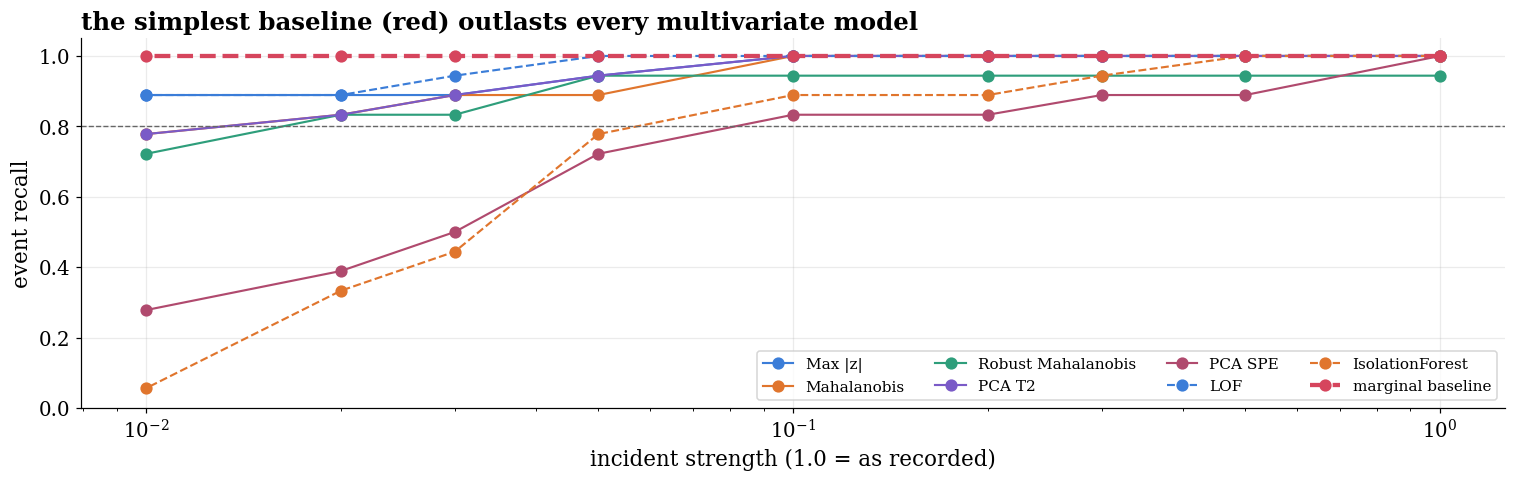

strength,recall at 0.05
Max |z|,0.944
Mahalanobis,0.889
Robust Mahalanobis,0.944
PCA T2,0.944
PCA SPE,0.722
LOF,1.000
IsolationForest,0.778
marginal baseline,1.000


{'step': 7,
 'trial': 'sweep incident strength',
 'metric': 'detection_floor',
 'value': 0.01,
 'verdict': 'the marginal baseline holds to 0.01; IsolationForest gives up at 0.1',
 'next_step': 'bootstrap the weak case before believing the ranking'}

In [13]:
rows = []
for strength, weak in weak_frames.items():
    got = scorecard(weak, raise_flags(weak, score_fleet(weak, models), thresholds),
                    windows).set_index("detector")
    row = {d: got.loc[d, "event_recall"] for d in DETECTORS}
    wb = pd.DataFrame({BASELINE: marginal_score(weak, FEATURES, estimate_mask)})
    row[BASELINE] = scorecard(weak, raise_flags(weak, wb, th_baseline),
                              windows).iloc[0].event_recall
    rows.append(pd.Series(row, name=strength))
recall_by_strength = pd.DataFrame(rows)
recall_by_strength.index.name = "strength"
display(recall_by_strength)

floors = pd.Series({c: min([i for i in recall_by_strength.index
                            if recall_by_strength.loc[i, c] >= 0.8], default=np.nan)
                    for c in recall_by_strength.columns}, name="detection floor")
display(floors.to_frame().T)

fig, ax = plt.subplots(figsize=(14, 4.6))
for k, det in enumerate(recall_by_strength.columns):
    ax.plot(recall_by_strength.index, recall_by_strength[det], marker="o",
            color=C["alert"] if det == BASELINE else PORT_C[k % len(PORT_C)],
            lw=2.8 if det == BASELINE else 1.4,
            ls=["-", "--", ":"][k // len(PORT_C)], label=det)
ax.axhline(0.8, color="0.4", ls="--", lw=0.9)
ax.set(xscale="log", xlabel="incident strength (1.0 = as recorded)", ylabel="event recall",
       ylim=(0, 1.05), title="the simplest baseline (red) outlasts every multivariate model")
ax.legend(fontsize=10, ncol=4, loc="lower right")
plt.show()
# 你的選擇 —— 要用多弱的事件來比較
# 下面每一步的比較都建立在某一個強度上。0.05 是這份 notebook 的選擇，理由是它剛好讓方法分得開。
# 換成 0.2 會看到大家又都滿分，換成 0.01 會看到只剩兩個還站著。改 LOOK_AT 再跑一次下一格。
LOOK_AT = 0.05
display(recall_by_strength.loc[[LOOK_AT]].T.rename(columns={LOOK_AT: f"recall at {LOOK_AT}"}))

ladder.record(7, "sweep incident strength", "detection_floor", floors[BASELINE],
              f"the marginal baseline holds to {floors[BASELINE]}; "
              f"IsolationForest gives up at {floors['IsolationForest']}",
              "bootstrap the weak case before believing the ranking")

## 第 8 步　試驗：弱事件下的排名可不可信

第 7 步排出了一個名次。在相信它之前先問一句：這個名次的誤差有多大。
十八個視窗是一個很小的樣本，重抽一次就可能換一個順序。

In [14]:
def bootstrap_recall(outcomes, n_boot=2000, seed=SEED):
    '''對視窗重抽，得到 recall 的信賴區間。證據的單位是事件，不是樣本。'''
    detected = np.asarray(outcomes["detected"], bool)
    rng = np.random.default_rng(seed)
    draws = detected[rng.integers(0, len(detected), size=(n_boot, len(detected)))].mean(axis=1)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return {"recall": round(float(detected.mean()), 3),
            "ci95": [round(float(lo), 3), round(float(hi), 3)]}


weak = weak_frames[0.05]
weak_flags = raise_flags(weak, score_fleet(weak, models), thresholds)
rows = []
for det in DETECTORS:
    boot = bootstrap_recall(window_outcomes(weak, weak_flags[det], windows))
    rows.append({"detector": det, "recall": boot["recall"],
                 "ci95_low": boot["ci95"][0], "ci95_high": boot["ci95"][1]})
ci = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)
display(ci)
maha = ci[ci["detector"] == "Mahalanobis"].iloc[0]
ladder.record(8, "bootstrap at strength 0.05", "ci_width",
              maha["ci95_high"] - maha["ci95_low"],
              f"{ci['recall'].iloc[1]:.3f} to {ci['recall'].iloc[0]:.3f} overlap; "
              f"the ranking is inside the interval",
              "ask what the multivariate models buy, if not recall")

,detector,recall,ci95_low,ci95_high
0,LOF,1.000,1.000,1.000
1,Max |z|,0.944,0.833,1.000
2,Robust Mahalanobis,0.944,0.833,1.000
3,PCA T2,0.944,0.833,1.000
4,Mahalanobis,0.889,0.722,1.000
5,IsolationForest,0.778,0.556,0.944
6,PCA SPE,0.722,0.500,0.889


{'step': 8,
 'trial': 'bootstrap at strength 0.05',
 'metric': 'ci_width',
 'value': 0.278,
 'verdict': '0.944 to 1.000 overlap; the ranking is inside the interval',
 'next_step': 'ask what the multivariate models buy, if not recall'}

### 那多變量模型是為了什麼

marginal baseline 的輸出是一個數字。它沒辦法回答「這個分數裡有多少是這一欄造成的」，因為它本來就
只看一欄。多變量模型的輸出可以拆，**第二部整個建立在這個能力上**。

## 第 9 步　試驗：參考期混進了事件

In [15]:
dirty_models = fit_fleet(df, (df["timestamp"] < CAL_START).to_numpy())
dirty_th = calibrate(df, score_fleet(df, dirty_models), calibrate_mask)
rows = []
for strength in (1.0, 0.3, 0.1, 0.05):
    weak = weak_frames[strength]
    clean = scorecard(weak, raise_flags(weak, score_fleet(weak, models), thresholds),
                      windows).set_index("detector")
    dirty = scorecard(weak, raise_flags(weak, score_fleet(weak, dirty_models), dirty_th),
                      windows).set_index("detector")
    rows.append(pd.Series({d: round(dirty.loc[d, "event_recall"]
                                    - clean.loc[d, "event_recall"], 3) for d in DETECTORS},
                          name=strength))
contamination = pd.DataFrame(rows)
contamination.index.name = "strength"
display(contamination[["Mahalanobis", "Robust Mahalanobis", "PCA T2", "PCA SPE",
                       "Max |z|", "LOF", "IsolationForest"]])
ladder.record(9, "contaminate the Phase I reference", "recall_lost_at_0.1",
              abs(contamination.loc[0.1, "Mahalanobis"]),
              f"robust covariance loses "
              f"{abs(contamination.loc[0.1, 'Robust Mahalanobis']):.3f} where the plain "
              f"estimator loses {abs(contamination.loc[0.1, 'Mahalanobis']):.3f}",
              "add indicators that carry information a single score cannot")

,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,Max |z|,LOF,IsolationForest
strength,,,,,,,
1.00,0.000,0.000,-0.056,-0.167,0.000,-0.111,0.000
0.30,-0.167,0.000,-0.056,-0.056,-0.056,0.000,0.000
0.10,-0.167,0.000,-0.111,0.000,-0.056,-0.056,-0.111
0.05,-0.111,-0.166,-0.166,-0.111,-0.055,-0.056,-0.278


{'step': 9,
 'trial': 'contaminate the Phase I reference',
 'metric': 'recall_lost_at_0.1',
 'value': 0.167,
 'verdict': 'robust covariance loses 0.000 where the plain estimator loses 0.167',
 'next_step': 'add indicators that carry information a single score cannot'}

參考期可信就不要買這個保險，事件紀錄不完整就值得買。
參考期可信就不要買，事件紀錄不完整就值得買。

## 第 10 到第 13 步　四種進階指標

到這裡每個指標都只看單一時刻。**下面四個各自加進一種單一時刻沒有的資訊**，而它們真正的用途要到
第二部才看得出來。

| 指標 | 加進什麼 | 分得出什麼 |
| --- | --- | --- |
| EWMA 與 CUSUM | 記憶 | 持續的偏移，對比瞬間的尖峰 |
| 一階差分 | 變化率 | 階梯式的位準改變，對比尖峰 |
| 滾動相關係數 | 欄位之間的關係 | 相關性斷裂，每一欄單獨看都正常 |
| 組成熵 | 分布形狀 | 封包種類的組成改變，與流量多寡無關 |

In [16]:
def ewma(values, lam=0.2):
    '''指數加權移動平均。lam 越小記憶越長。'''
    x = np.asarray(values, float)
    out = np.empty(len(x))
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = lam * x[i] + (1 - lam) * out[i - 1]
    return out


def cusum(values, k=0.5):
    '''單邊 CUSUM。只累積超過 k 的部分，所以雜訊不會把它推走。'''
    x = np.asarray(values, float)
    out = np.zeros(len(x))
    for i in range(1, len(x)):
        out[i] = max(0.0, out[i - 1] + x[i] - k)
    return out

In [17]:
# 兩個關係型的指標：一個看兩欄的關係，一個看組成的比例
def rolling_correlation_break(frame, a, b, estimate_mask, window=72):
    '''兩欄的滾動相關係數，離它在參考期的常態有多遠。每一欄單看都可能正常。'''
    out = np.zeros(len(frame))
    for _, group in frame.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        rolling = group[a].rolling(window, min_periods=window // 2).corr(group[b])
        rolling = rolling.fillna(0.0).to_numpy()
        reference = rolling[estimate_mask[idx]]
        centre = np.median(reference)
        spread = max(np.median(np.abs(reference - centre)) * MAD_TO_SIGMA, 1e-6)
        out[idx] = np.abs(rolling - centre) / spread
    return pd.Series(out, index=frame.index)


def composition_entropy(raw):
    '''封包種類組成的夏農熵。與流量多寡無關，只看比例。'''
    eps = 1e-12
    parts = pd.DataFrame({
        "ucast": raw["INUCASTPKTS"] + raw["OUTUCASTPKTS"],
        "bcast": raw["INBROADCASTPKTS"] + raw["OUTBROADCASTPKTS"],
        "mcast": raw["INMULTICASTPKTS"] + raw["OUTMULTICASTPKTS"]})
    shares = parts.div(parts.sum(axis=1) + eps, axis=0).clip(lower=eps)
    return -(shares * np.log(shares)).sum(axis=1)

In [18]:
# 上面四個算出來的東西單位都不一樣，這兩個把任何一條序列換到同一把尺上
def deviation_from_reference(values, frame, estimate_mask):
    '''任何一條序列，換算成離它自己參考期常態的 robust 距離。'''
    values = pd.Series(np.asarray(values, float), index=frame.index)
    out = np.zeros(len(frame))
    for _, group in frame.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        x = values.loc[idx].to_numpy(float)
        reference = x[estimate_mask[idx]]
        centre = np.median(reference)
        spread = max(np.median(np.abs(reference - centre)) * MAD_TO_SIGMA,
                     reference.std(), 1e-9)
        out[idx] = np.abs(x - centre) / spread
    return pd.Series(out, index=frame.index)


def by_port(frame, series, transform):
    '''把一個逐點的轉換套在每個 port 自己的時間序列上。'''
    values = pd.Series(np.asarray(series, float), index=frame.index)
    out = np.zeros(len(frame))
    for _, group in frame.groupby("port_id", sort=True):
        idx = group.index.to_numpy()
        out[idx] = transform(values.loc[idx].to_numpy())
    return pd.Series(out, index=frame.index)

In [19]:
def build_indicators(target_frame, target_raw):
    '''六個指標放在同一張表上，全部是越大越異常。'''
    base = score_fleet(target_frame, models)["Max |z|"]
    return pd.DataFrame({
        "instant": base,
        "EWMA memory": by_port(target_frame, base, lambda x: ewma(x, lam=0.2)),
        "CUSUM drift": by_port(target_frame, base, lambda x: cusum(x, k=0.5)),
        "jump (first difference)": by_port(target_frame, base,
                                           lambda x: np.abs(np.r_[0.0, np.diff(x)])),
        "correlation break": rolling_correlation_break(target_frame, "traffic_bps",
                                                       "packets_pps", estimate_mask),
        "composition entropy": deviation_from_reference(composition_entropy(target_raw),
                                                        target_frame, estimate_mask),
    })


indicators = build_indicators(df, telemetry)
indicator_th = calibrate(df, indicators, calibrate_mask)
indicator_flags = raise_flags(df, indicators, indicator_th)
display(scorecard(df, indicator_flags, windows))

,detector,event_recall,median_delay_min,false_onsets,false_per_port_day
0,instant,1.000,0.0,165,1.10
1,EWMA memory,1.000,0.0,90,0.60
2,CUSUM drift,0.444,0.0,17,0.11
3,jump (first difference),1.000,0.0,90,0.60
4,correlation break,0.222,20.0,27,0.18
5,composition entropy,0.889,0.0,212,1.41


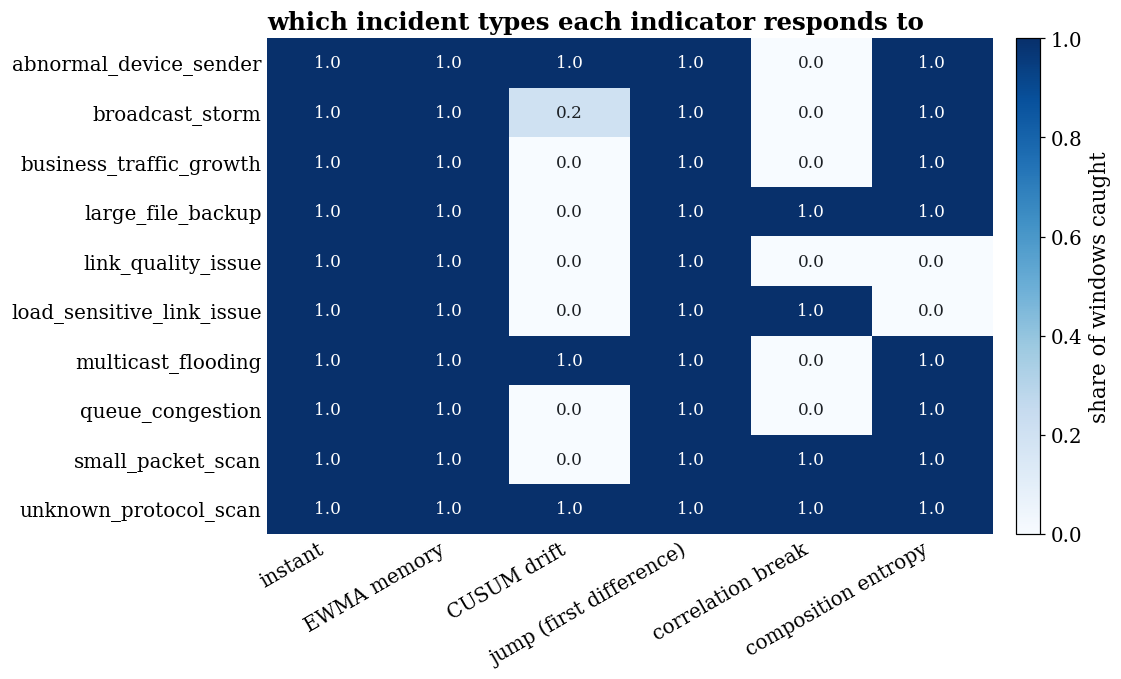

,event_recall,median_delay_min,false_onsets,false_per_port_day
detector,,,,
instant,0.944,0.0,166,1.11
EWMA memory,0.778,0.0,89,0.59
CUSUM drift,0.167,0.0,3,0.02
jump (first difference),0.944,0.0,89,0.59
correlation break,0.000,NaN,14,0.09
composition entropy,0.833,0.0,212,1.41


{'step': 13,
 'trial': 'four temporal and relational indicators',
 'metric': 'event_recall_at_0.05',
 'value': 0.944,
 'verdict': 'instant survives attenuation best; each indicator sees a different subset',
 'next_step': 'carry the per-feature decomposition into root cause'}

In [20]:
# 每個指標各自對哪些故障種類有反應。這才是它們的用處：不是誰的 recall 高，
# 是誰看得見別人看不見的。
rows = []
for name in indicators.columns:
    got = window_outcomes(df, indicator_flags[name], windows)
    rows.append(pd.Series(got.groupby("event_type")["detected"].mean(), name=name))
coverage = pd.DataFrame(rows).fillna(0.0)
heatmap(coverage.T, fmt="{:.1f}", cbar_label="share of windows caught",
        title="which incident types each indicator responds to")

weak_ind = build_indicators(weak_frames[0.05], attenuate(telemetry, counterfactual, 0.05))
weak_card = scorecard(weak_frames[0.05], raise_flags(weak_frames[0.05], weak_ind, indicator_th),
                      windows).set_index("detector")
display(weak_card)
best = weak_card["event_recall"].idxmax()
ladder.record(13, "four temporal and relational indicators", "event_recall_at_0.05",
              weak_card.loc[best, "event_recall"],
              f"{best} survives attenuation best; each indicator sees a different subset",
              "carry the per-feature decomposition into root cause")

## 第 14 步　讀出來的東西

在偵測上這些指標沒有價值，第 5 步已經全部抓到了。在根因上它們價值很大，第 26 步會把「觸發了哪幾個
指標」變成可以評分的東西。

---
# 第二部　承重：根因分析

偵測回答「有沒有事」。工程師收到告警之後要回答的是另外幾個問題，而前面五節沒有量過任何一個。

| 問題 | 量法 | 真值 |
| --- | --- | --- |
| 哪一個 counter 在動 | attribution hit@k | `FAULT_SIGNATURE`，由事件描述寫成 |
| 影響到哪些 port，誰先動 | localization、onset ordering | telemetry 的 `event_id` 與 `port_id` |
| 這是哪一種故障 | cause typing | `event_type` |
| 證據夠不夠下結論 | evidence sufficiency | 前兩名候選的差距 |
| 這是不是我們自己排的 | suppression | `change_calendar.csv` |

`FAULT_SIGNATURE` 從事件描述寫成，不是從資料擬合的。用同一份資料推出來的真值表去評分歸因，量到的
是自己的假設。表和資料不一致時，那是關於其中一方的發現，不是回頭改表的理由。

## 第 15 步　真值表，以及亂猜的水準

In [21]:
FAULT_SIGNATURE = {
    "business_traffic_growth":   {"traffic_bps", "packets_pps"},
    "small_packet_scan":         {"avg_pkt_bytes", "packets_pps"},
    "large_file_backup":         {"avg_pkt_bytes", "traffic_bps"},
    "queue_congestion":          {"discards_pps", "discard_rate"},
    "link_quality_issue":        {"errors_pps", "error_rate"},
    "load_sensitive_link_issue": {"errors_pps", "error_rate", "traffic_bps"},
    "broadcast_storm":           {"broadcast_ratio"},
    "multicast_flooding":        {"multicast_ratio"},
    "abnormal_device_sender":    {"tx_ratio", "traffic_bps"},
    "unknown_protocol_scan":     {"unknown_proto_pps"},
}


def random_baseline(k=1, features=None):
    features = MODEL_FEATURES if features is None else features
    '''亂猜的 hit@k。有這條線，一張命中率的表才知道要贏過什麼。'''
    rates = []
    for signature in FAULT_SIGNATURE.values():
        present = len(signature & set(features))
        miss = 1.0
        for i in range(k):
            miss *= max(len(features) - present - i, 0) / max(len(features) - i, 1)
        rates.append(1 - miss)
    return round(float(np.mean(rates)), 3)


CHANCE = random_baseline(1)
print(f"random top-1 pick scores hit@1 {CHANCE}, hit@3 {random_baseline(3)}")
display(pd.Series({k: ", ".join(sorted(v)) for k, v in FAULT_SIGNATURE.items()}
                  ).to_frame("signature counters"))

random top-1 pick scores hit@1 0.15, hit@3 0.41


,signature counters
business_traffic_growth,"packets_pps, traffic_bps"
small_packet_scan,"avg_pkt_bytes, packets_pps"
large_file_backup,"avg_pkt_bytes, traffic_bps"
queue_congestion,"discard_rate, discards_pps"
link_quality_issue,"error_rate, errors_pps"
load_sensitive_link_issue,"error_rate, errors_pps, traffic_bps"
broadcast_storm,broadcast_ratio
multicast_flooding,multicast_ratio
abnormal_device_sender,"traffic_bps, tx_ratio"
unknown_protocol_scan,unknown_proto_pps


## 第 16 步　試驗：最直覺的歸因，哪一欄的偏離最大

In [22]:
DETECTOR = "Mahalanobis"


def peak_row(frame, scores, window, detector=DETECTOR):
    '''一個視窗裡分數最高的那一列。歸因都在這一列上做。'''
    idx = frame.index[(frame["port_id"] == window.port_id)
                      & frame["timestamp"].between(window.start, window.end)]
    return idx, scores.loc[idx, detector].idxmax()


def share(values):
    total = float(np.sum(values))
    return np.asarray(values, float) / total if total > 0 else np.full(len(values), np.nan)


def score_one(model, z_row, detector=DETECTOR):
    '''單獨一列的分數，歸因要靠它反覆重算。'''
    z = np.asarray(z_row, float).reshape(1, -1)
    return float(model.score_matrix(z)[detector][0])

In [23]:
# 第一種歸因，以及量所有歸因方法用的同一套流程
def attribution_absz(model, z_row, spe_row):
    '''R0：每一欄的偏離量佔多少。最直覺，也最容易被比值的分母騙。'''
    return pd.Series(share(np.abs(z_row)), index=MODEL_FEATURES)


def attribute(model, frame, scores, window, method):
    '''在視窗的峰值那一列上，跑一種歸因方法。'''
    idx, peak = peak_row(frame, scores, window)
    local = frame.loc[idx].reset_index(drop=True)
    z_all = model.standardize(local)
    position = list(idx).index(peak)
    return method(model, z_all[position], model.per_feature_spe(z_all)[position])


def attribution_scoreboard(methods, frame, scores, models, windows):
    '''每個歸因方法在十八個視窗上的 hit@1 與 hit@3。'''
    rows = []
    for w in windows.itertuples():
        row = {"event_id": w.event_id, "event_type": w.event_type, "port": w.port_id[-4:]}
        for name, method in methods.items():
            ranked = attribute(models[w.port_id], frame, scores, w,
                               method).sort_values(ascending=False)
            row[f"{name} top1"] = ranked.index[0]
            for k in (1, 3):
                row[f"{name} hit@{k}"] = bool(set(ranked.index[:k])
                                              & FAULT_SIGNATURE[w.event_type])
        rows.append(row)
    return pd.DataFrame(rows)


def summarise(table, methods):
    return pd.DataFrame([{"attribution": name,
                          "hit@1": round(float(table[f"{name} hit@1"].mean()), 3),
                          "hit@3": round(float(table[f"{name} hit@3"].mean()), 3)}
                         for name in methods]).sort_values(
                             "hit@1", ascending=False).reset_index(drop=True)

In [24]:
# 錯誤示範：對 marginal baseline 做歸因
# 它的分數就是「最大的那一維」，所以任何歸因都只會把 100% 給那一維。這不是解釋，
# 這是把 argmax 重講一次。第 7 步說多變量模型的價值在可以拆解，指的就是這件事。
w_demo = windows[windows["event_id"] == "A"].iloc[0]
idx_demo, peak_demo = peak_row(df, scores, w_demo)
z_demo = models[w_demo.port_id].standardize(
    df.loc[idx_demo].reset_index(drop=True))[list(idx_demo).index(peak_demo)]


def baseline_attribution(z_row):
    contribution = np.zeros(len(MODEL_FEATURES))
    contribution[int(np.argmax(np.abs(z_row)))] = 1.0
    return pd.Series(contribution, index=MODEL_FEATURES)


wrong_way("把 max |z| 當成可以拆解的分數",
          lambda: dict(baseline_attribution(z_demo)[baseline_attribution(z_demo) > 0]))

methods = {"R0 max |z|": attribution_absz}
table = attribution_scoreboard(methods, df, scores, models, windows)
display(table[["event_id", "event_type", "port", "R0 max |z| top1", "R0 max |z| hit@1"]])
r0 = summarise(table, methods)
display(r0)
ladder.record(16, "attribution: largest |z|", "hit@1", r0["hit@1"].iloc[0],
              f"{r0['hit@1'].iloc[0]}, and the misses share one mechanism",
              "look at what the two failures have in common")

=== 錯誤示範：把 max |z| 當成可以拆解的分數 ===
  沒有報錯，結果是：{'nonucast_ratio': np.float64(1.0)}
  沒有報錯不代表算對了。這一種要靠你自己看出來。


,event_id,event_type,port,R0 max |z| top1,R0 max |z| hit@1
0,A,business_traffic_growth,7430,nonucast_ratio,False
1,B,small_packet_scan,7428,nonucast_ratio,False
2,C,large_file_backup,7431,nonucast_ratio,False
3,D,queue_congestion,7427,discards_pps,True
4,E,link_quality_issue,7429,errors_pps,True
5,F,load_sensitive_link_issue,7427,errors_pps,True
6,G,broadcast_storm,7431,nonucast_ratio,False
7,G,broadcast_storm,7430,nonucast_ratio,False
8,G,broadcast_storm,7429,nonucast_ratio,False
9,G,broadcast_storm,7428,nonucast_ratio,False


,attribution,hit@1,hit@3
0,R0 max |z|,0.556,0.889


{'step': 16,
 'trial': 'attribution: largest |z|',
 'metric': 'hit@1',
 'value': 0.556,
 'verdict': '0.556, and the misses share one mechanism',
 'next_step': 'look at what the two failures have in common'}

## 第 17 步　診斷：比值的分母在動

every window R0 got wrong:


,event_id,event_type,port,R0 max |z| top1
0,A,business_traffic_growth,7430,nonucast_ratio
1,B,small_packet_scan,7428,nonucast_ratio
2,C,large_file_backup,7431,nonucast_ratio
6,G,broadcast_storm,7431,nonucast_ratio
7,G,broadcast_storm,7430,nonucast_ratio
8,G,broadcast_storm,7429,nonucast_ratio
9,G,broadcast_storm,7428,nonucast_ratio
10,G,broadcast_storm,7427,nonucast_ratio



event A, business_traffic_growth, at its peak on port-id7430:


,at the peak,normal median,times normal
traffic_bps,1.641606e+06,336974.435733,4.87
packets_pps,2.992467e+02,56.245000,5.32
multicast_ratio,2.561989e-03,0.004841,0.53
broadcast_ratio,1.470359e-03,0.002766,0.53


,at the peak,normal median,times normal
INMULTICASTPKTS,136,48.0,2.83
OUTMULTICASTPKTS,94,33.0,2.85
INUCASTPKTS,57922,10578.0,5.48
OUTUCASTPKTS,31021,5892.5,5.26


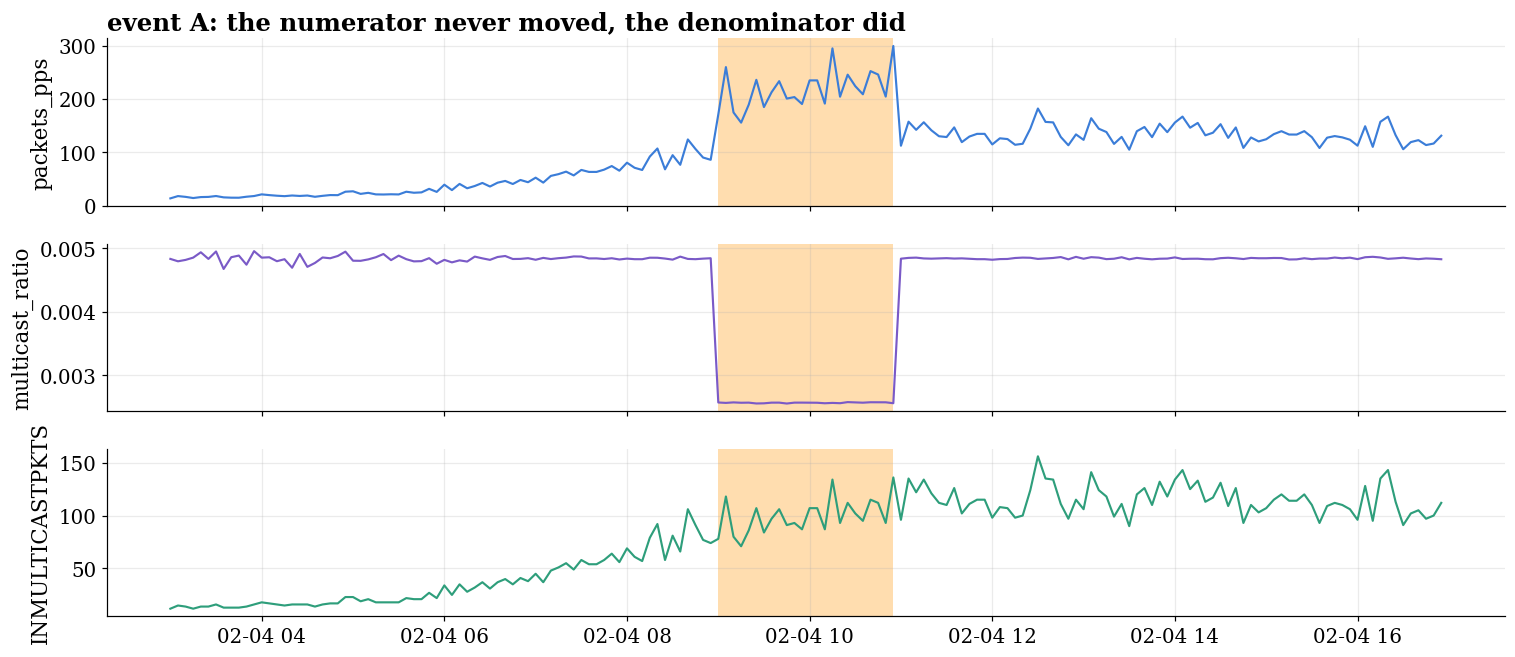

In [25]:
print("every window R0 got wrong:")
display(table[~table["R0 max |z| hit@1"]][["event_id", "event_type", "port", "R0 max |z| top1"]])

w = windows[windows["event_id"] == "A"].iloc[0]
idx, peak = peak_row(df, scores, w)
reference = df[(df["port_id"] == w.port_id) & ~is_event]
show = ["traffic_bps", "packets_pps", "multicast_ratio", "broadcast_ratio"]
compare = pd.DataFrame({"at the peak": df.loc[peak, show],
                        "normal median": reference[show].median()})
compare["times normal"] = (compare["at the peak"] / compare["normal median"]).round(2)
print(f"\nevent A, business_traffic_growth, at its peak on {w.port_id}:")
display(compare)
counts = ["INMULTICASTPKTS", "OUTMULTICASTPKTS", "INUCASTPKTS", "OUTUCASTPKTS"]
raw_compare = pd.DataFrame({"at the peak": telemetry.loc[peak, counts],
                            "normal median": telemetry.loc[reference.index, counts].median()})
raw_compare["times normal"] = (raw_compare["at the peak"]
                               / raw_compare["normal median"]).round(2)
display(raw_compare)

# 把分子與分母畫在一起，比值的假象就看得見了。
g = df[df["port_id"] == w.port_id]
window_slice = g["timestamp"].between(w.start - pd.Timedelta(hours=6),
                                      w.end + pd.Timedelta(hours=6))
fig, axes = plt.subplots(3, 1, figsize=(14, 6.2), sharex=True)
for ax, column, colour in ((axes[0], "packets_pps", C["signal"]),
                           (axes[1], "multicast_ratio", C["score"]),
                           (axes[2], "INMULTICASTPKTS", C["peer"])):
    series = (g.loc[window_slice, column] if column in g
              else telemetry.loc[g.index[window_slice], column])
    ax.plot(g.loc[window_slice, "timestamp"], series, lw=1.4, color=colour)
    ax.axvspan(w.start, w.end, color=C["truth"], alpha=0.35, lw=0)
    ax.set_ylabel(column)
axes[0].set_title("event A: the numerator never moved, the denominator did")
plt.show()

R0 錯的每一個視窗都指向同一欄，`nonucast_ratio`，而它的正常帶 MAD 小到任何一點變動都是幾十個
sigma。八個視窗、一個機制。**下一步：** 換一個不會被分母騙的歸因方式，先試最省事的。

## 第 18 到第 19 步　試驗與診斷：免費的拆解

In [26]:
def attribution_spe(model, z_row, spe_row):
    '''R1：PCA 重建誤差的逐欄拆解。免費，因為可加的分數會自己拆開。'''
    return pd.Series(share(spe_row), index=MODEL_FEATURES)


methods["R1 PCA SPE share"] = attribution_spe
table = attribution_scoreboard(methods, df, scores, models, windows)
display(summarise(table, methods))
print("what R1 named, across all 18 windows:")
display(table["R1 PCA SPE share top1"].value_counts().to_frame("windows"))

shape = pd.DataFrame([{"feature": f,
                       "excess_kurtosis": round(float(stats.kurtosis(
                           df.loc[estimate_mask, f].to_numpy())), 1),
                       "zero_frac": round(float((df[f] == 0).mean()), 3)}
                      for f in MODEL_FEATURES]).sort_values("excess_kurtosis", ascending=False)
display(shape.head(5))
ladder.record(18, "attribution: free PCA SPE split", "hit@1",
              summarise(table, methods).query(
                  "attribution == 'R1 PCA SPE share'")["hit@1"].iloc[0],
              f"barely above the {CHANCE} chance floor",
              "find which feature is eating the sum")

,attribution,hit@1,hit@3
0,R0 max |z|,0.556,0.889
1,R1 PCA SPE share,0.222,0.333


what R1 named, across all 18 windows:


,windows
R1 PCA SPE share top1,
discard_rate,10
packets_pps,3
errors_pps,2
error_rate,2
discards_pps,1


,feature,excess_kurtosis,zero_frac
10,error_rate,248.3,0.976
11,discard_rate,170.9,0.913
4,unknown_proto_pps,101.7,0.990
2,errors_pps,37.0,0.976
3,discards_pps,11.8,0.913


{'step': 18,
 'trial': 'attribution: free PCA SPE split',
 'metric': 'hit@1',
 'value': 0.222,
 'verdict': 'barely above the 0.15 chance floor',
 'next_step': 'find which feature is eating the sum'}

**下一步：** 不要用分數的內部結構，直接用擾動去問。

## 第 20 到第 21 步　試驗與診斷：把一欄拉回正常

In [27]:
def attribution_leave_one_out(model, z_row, spe_row):
    '''R2：把第 j 欄換回季節正常值，分數掉多少就算它的貢獻。'''
    base = score_one(model, z_row)
    drops = []
    for j in range(len(MODEL_FEATURES)):
        perturbed = np.array(z_row, float)
        perturbed[j] = 0.0
        drops.append(max(base - score_one(model, perturbed), 0.0))
    return pd.Series(share(drops), index=MODEL_FEATURES)


methods["R2 leave-one-out"] = attribution_leave_one_out
table = attribution_scoreboard(methods, df, scores, models, windows)
display(summarise(table, methods))

model = models["port-id7430"]
w = windows[windows["event_id"] == "A"].iloc[0]
idx, peak = peak_row(df, scores, w)
local = df.loc[idx].reset_index(drop=True)
z_row = model.standardize(local)[list(idx).index(peak)]
# 哪兩欄會互相抵銷不用猜，量出來就知道：參考期上相關係數最高的那一對。
correlation = df.loc[estimate_mask, FEATURES].corr().abs().to_numpy(copy=True)
np.fill_diagonal(correlation, 0.0)
a, b = np.unravel_index(correlation.argmax(), correlation.shape)
print(f"參考期上最黏在一起的兩欄：{FEATURES[a]} 與 {FEATURES[b]}")
print(f"它們的相關係數 {correlation[a, b]:.3f}，事件 A 的峰值上兩欄一起動")
display(pd.DataFrame({"|z| at the peak": np.abs(z_row),
                      "R2 leave-one-out": attribution_leave_one_out(model, z_row, None)},
                     index=MODEL_FEATURES).sort_values("|z| at the peak", ascending=False).head(5))
ladder.record(20, "attribution: leave-one-out", "hit@1",
              summarise(table, methods).query(
                  "attribution == 'R2 leave-one-out'")["hit@1"].iloc[0],
              "correlated counters cancel each other out",
              "ask what each feature keeps, not what it removes")

,attribution,hit@1,hit@3
0,R0 max |z|,0.556,0.889
1,R2 leave-one-out,0.556,0.889
2,R1 PCA SPE share,0.222,0.333


參考期上最黏在一起的兩欄：traffic_bps 與 packets_pps
它們的相關係數 0.980，事件 A 的峰值上兩欄一起動


,|z| at the peak,R2 leave-one-out
nonucast_ratio,184.377996,0.722940
multicast_ratio,93.584689,0.171325
broadcast_ratio,50.607652,0.105732
traffic_bps,29.903532,0.000000
packets_pps,28.580819,0.000000


{'step': 20,
 'trial': 'attribution: leave-one-out',
 'metric': 'hit@1',
 'value': 0.556,
 'verdict': 'correlated counters cancel each other out',
 'next_step': 'ask what each feature keeps, not what it removes'}

## 第 22 步　修正：只有這一欄偏離的話，分數還剩多少

,attribution,hit@1,hit@3
0,R3 counterfactual,0.611,1.000
1,R0 max |z|,0.556,0.889
2,R2 leave-one-out,0.556,0.889
3,R1 PCA SPE share,0.222,0.333


,event_id,event_type,port,R0 max |z| top1,R3 counterfactual top1
0,A,business_traffic_growth,7430,nonucast_ratio,nonucast_ratio
1,B,small_packet_scan,7428,nonucast_ratio,packets_pps
2,C,large_file_backup,7431,nonucast_ratio,nonucast_ratio
3,D,queue_congestion,7427,discards_pps,discards_pps
4,E,link_quality_issue,7429,errors_pps,errors_pps
5,F,load_sensitive_link_issue,7427,errors_pps,errors_pps
6,G,broadcast_storm,7431,nonucast_ratio,nonucast_ratio
7,G,broadcast_storm,7430,nonucast_ratio,nonucast_ratio


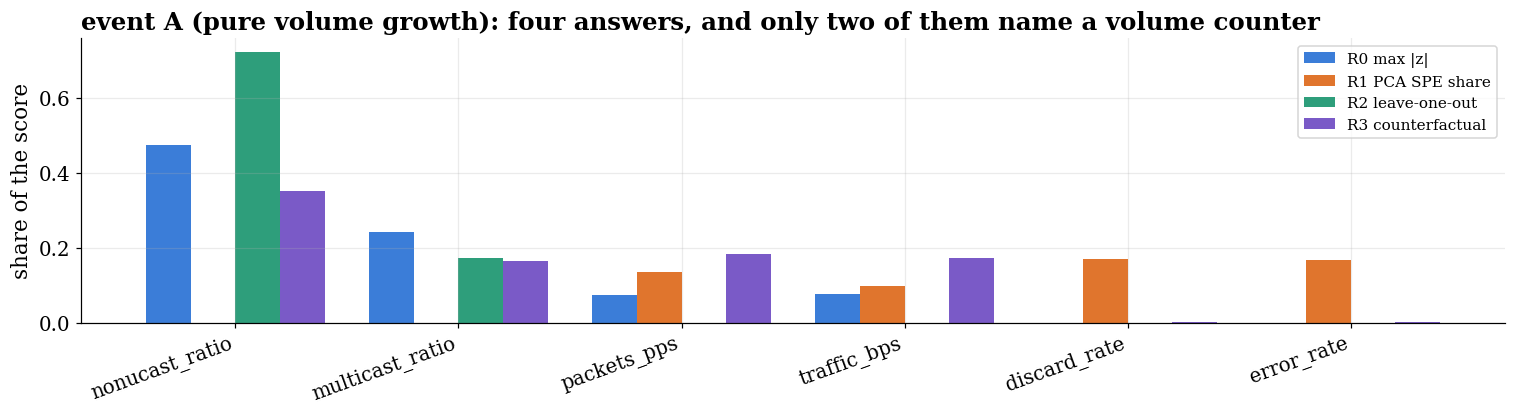

{'step': 22,
 'trial': 'attribution: counterfactual',
 'metric': 'hit@1',
 'value': 0.611,
 'verdict': 'hit@3 reaches 1.000: the right counter is always in the top three',
 'next_step': 'try pairs, for the faults that live in a relationship'}

In [28]:
def attribution_counterfactual(model, z_row, spe_row):
    '''R3：只留下第 j 欄，其他全部歸零，分數還剩多少。相關的兩欄不會互相抵銷。'''
    kept = []
    for j in range(len(MODEL_FEATURES)):
        alone = np.zeros(len(MODEL_FEATURES))
        alone[j] = z_row[j]
        kept.append(max(score_one(model, alone), 0.0))
    return pd.Series(share(kept), index=MODEL_FEATURES)


methods["R3 counterfactual"] = attribution_counterfactual
table = attribution_scoreboard(methods, df, scores, models, windows)
summary = summarise(table, methods)
display(summary)
display(table[["event_id", "event_type", "port",
               "R0 max |z| top1", "R3 counterfactual top1"]].head(8))
compare_methods = pd.DataFrame({
    name: attribute(models["port-id7430"], df, scores,
                    windows[windows["event_id"] == "A"].iloc[0], method)
    for name, method in methods.items()})
top = compare_methods.max(axis=1).sort_values(ascending=False).head(6).index
fig, ax = plt.subplots(figsize=(14, 4.0))
width = 0.2
for k, name in enumerate(methods):
    ax.bar(np.arange(len(top)) + (k - 1.5) * width, compare_methods.loc[top, name],
           width=width, label=name, color=PORT_C[k % len(PORT_C)])
ax.set_xticks(np.arange(len(top)), top, rotation=20, ha="right")
ax.set(ylabel="share of the score", title="event A (pure volume growth): four answers, "
       "and only two of them name a volume counter")
ax.legend(fontsize=10)
plt.show()

ladder.record(22, "attribution: counterfactual", "hit@1",
              summary.query("attribution == 'R3 counterfactual'")["hit@1"].iloc[0],
              "hit@3 reaches 1.000: the right counter is always in the top three",
              "try pairs, for the faults that live in a relationship")

## 第 23 步　試驗：成對歸因

前面四個方法都假設「原因是某一欄」。有些故障不是這樣，它是兩欄之間的關係壞掉，而兩欄各自都還在
正常帶裡面。第 12 步的 correlation break 指標就是為這種事準備的。

成對歸因問的是：只留下第 j 與第 k 欄，分數剩多少，而這個數字比兩欄各自單獨留下來的最大值高多少。
高出來的部分就是這一對的交互作用。

In [29]:
def pair_interaction(model, z_row, top=5):
    '''只留下一對欄位的分數，減掉兩欄各自單獨的較大值。剩下的是這一對的交互作用。'''
    alone = {}
    for j in range(len(MODEL_FEATURES)):
        v = np.zeros(len(MODEL_FEATURES))
        v[j] = z_row[j]
        alone[j] = score_one(model, v)
    ranked = sorted(alone, key=alone.get, reverse=True)[:top]
    rows = []
    for a in range(len(ranked)):
        for b in range(a + 1, len(ranked)):
            j, k = ranked[a], ranked[b]
            v = np.zeros(len(MODEL_FEATURES))
            v[j], v[k] = z_row[j], z_row[k]
            joint = score_one(model, v)
            rows.append({"pair": f"{MODEL_FEATURES[j]} + {MODEL_FEATURES[k]}", "joint": round(joint, 1),
                         "best_alone": round(max(alone[j], alone[k]), 1),
                         "interaction": round(joint - max(alone[j], alone[k]), 1)})
    return pd.DataFrame(rows).sort_values("interaction", ascending=False).reset_index(drop=True)


rows = []
for w in windows.drop_duplicates("event_id").itertuples():
    idx, peak = peak_row(df, scores, w)
    local = df.loc[idx].reset_index(drop=True)
    z_row = models[w.port_id].standardize(local)[list(idx).index(peak)]
    best = pair_interaction(models[w.port_id], z_row).iloc[0]
    rows.append({"event_id": w.event_id, "event_type": w.event_type,
                 "strongest pair": best["pair"], "interaction": best["interaction"],
                 "joint": best["joint"],
                 "pair_dominated": bool(best["interaction"] > 0.5 * best["joint"])})
pairs = pd.DataFrame(rows)
display(pairs)
ladder.record(23, "attribution: pair interaction", "share_pair_dominated",
              float(pairs["pair_dominated"].mean()),
              "reports whether a fault lives in one counter or in a relationship",
              "turn the named counter into a named fault type")

,event_id,event_type,strongest pair,interaction,joint,pair_dominated
0,A,business_traffic_growth,traffic_bps + multicast_ratio,15.1,55.1,False
1,B,small_packet_scan,packets_pps + nonucast_ratio,30.5,336.5,False
2,C,large_file_backup,nonucast_ratio + multicast_ratio,14.6,151.1,False
3,D,queue_congestion,nonucast_ratio + discard_rate,69.0,503.0,False
4,E,link_quality_issue,unknown_proto_pps + avg_pkt_bytes,0.3,9.0,False
5,F,load_sensitive_link_issue,error_rate + traffic_bps,3.0,807.6,False
6,G,broadcast_storm,discards_pps + broadcast_ratio,320.4,1183.3,False
7,H,multicast_flooding,multicast_ratio + discards_pps,131.2,1075.5,False
8,I,abnormal_device_sender,multicast_ratio + broadcast_ratio,9.0,42.5,False
9,J,unknown_protocol_scan,nonucast_ratio + packets_pps,12.3,77.5,False


{'step': 23,
 'trial': 'attribution: pair interaction',
 'metric': 'share_pair_dominated',
 'value': 0.0,
 'verdict': 'reports whether a fault lives in one counter or in a relationship',
 'next_step': 'turn the named counter into a named fault type'}

`interaction` 相對於 `joint` 很小，表示這個故障確實是單一欄位造成的，看那一欄就夠了。兩者接近，
表示要同時看兩欄才解釋得了，單欄的歸因會漏掉一半。

這一欄不會改善 hit@1，它回答的是另一個問題：**這份歸因可不可以只講一個 counter。**

## 第 24 到第 25 步　試驗與修正：從 counter 到故障種類

In [30]:
def type_by_set_match(shares, k=3):
    '''最直覺的作法：前 k 名跟 signature 取交集，比 Jaccard。'''
    top = set(shares.sort_values(ascending=False).index[:k])
    scored = [(len(top & sig) / len(top | sig), name)
              for name, sig in sorted(FAULT_SIGNATURE.items())]
    best = max(scored)
    return best[1] if best[0] > 0 else "unclassified"


def type_scores(shares, floor=0.05):
    '''每一種故障的分數：coverage 乘 specificity。
    coverage 是份額落在 signature 上的比例，specificity 是 signature 裡真的動了的欄位比例。
    只看 coverage，signature 大的種類會靠包含關係贏；只看集合交集，單欄 signature 會平手。'''
    scored = []
    for name, signature in sorted(FAULT_SIGNATURE.items()):
        present = [f for f in signature if f in shares.index]
        if not present:
            continue
        coverage = float(shares[present].sum())
        specificity = float(np.mean([shares[f] >= floor for f in present]))
        scored.append({"type": name, "score": round(coverage * specificity, 3)})
    return pd.DataFrame(scored).sort_values("score", ascending=False).reset_index(drop=True)


def type_by_mass(shares):
    ranked = type_scores(shares)
    return ranked["type"].iloc[0] if ranked["score"].iloc[0] > 0 else "unclassified"

,event_id,true_type,set match,mass x specificity,set match ok,mass x specificity ok
0,A,business_traffic_growth,business_traffic_growth,business_traffic_growth,True,True
1,B,small_packet_scan,multicast_flooding,business_traffic_growth,False,False
2,C,large_file_backup,multicast_flooding,multicast_flooding,False,False
3,D,queue_congestion,queue_congestion,queue_congestion,True,True
4,E,link_quality_issue,link_quality_issue,link_quality_issue,True,True
5,F,load_sensitive_link_issue,load_sensitive_link_issue,link_quality_issue,True,False
6,G,broadcast_storm,broadcast_storm,broadcast_storm,True,True
7,G,broadcast_storm,broadcast_storm,broadcast_storm,True,True
8,G,broadcast_storm,broadcast_storm,broadcast_storm,True,True
9,G,broadcast_storm,broadcast_storm,queue_congestion,True,False


set matching        0.556
mass x specificity  0.667

event G attribution shares, which set matching threw away:


,share
nonucast_ratio,0.661
discards_pps,0.160
broadcast_ratio,0.151
discard_rate,0.018


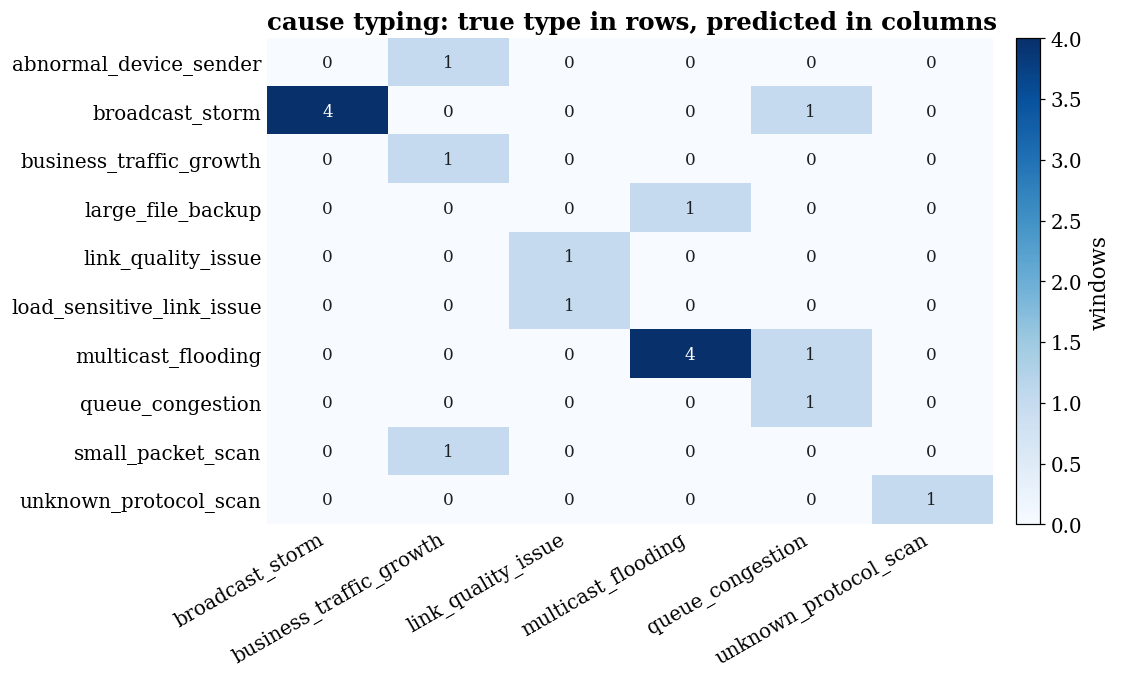

{'step': 25,
 'trial': 'cause typing by mass and specificity',
 'metric': 'type_accuracy',
 'value': 0.6667,
 'verdict': 'the residual errors are genuine disagreements with the table',
 'next_step': 'add a second, independent axis of evidence'}

In [31]:
# 同樣十八個視窗，同一套歸因份額，兩種判型方式各判一次
rows = []
for w in windows.itertuples():
    shares = attribute(models[w.port_id], df, scores, w, attribution_counterfactual)
    rows.append({"event_id": w.event_id, "true_type": w.event_type,
                 "set match": type_by_set_match(shares),
                 "mass x specificity": type_by_mass(shares)})
typing = pd.DataFrame(rows)
for column in ("set match", "mass x specificity"):
    typing[f"{column} ok"] = typing[column] == typing["true_type"]
display(typing)
print(f"set matching        {typing['set match ok'].mean():.3f}")
print(f"mass x specificity  {typing['mass x specificity ok'].mean():.3f}")

storm = windows[windows["event_id"] == "G"].iloc[0]
shares = attribute(models[storm.port_id], df, scores, storm, attribution_counterfactual)
print("\nevent G attribution shares, which set matching threw away:")
display(shares.sort_values(ascending=False).head(4).round(3).to_frame("share"))

heatmap(pd.crosstab(typing["true_type"], typing["mass x specificity"]),
        fmt="{:.0f}", cbar_label="windows",
        title="cause typing: true type in rows, predicted in columns")
ladder.record(24, "cause typing by set matching", "type_accuracy",
              typing["set match ok"].mean(),
              "single-counter signatures tie and the tie breaks on sort order",
              "weight by attributed mass and by specificity")
ladder.record(25, "cause typing by mass and specificity", "type_accuracy",
              typing["mass x specificity ok"].mean(),
              "the residual errors are genuine disagreements with the table",
              "add a second, independent axis of evidence")

剩下的錯誤是真的：load sensitive link issue 的 signature 包含 link quality issue 的，兩者的差別是
當時流量高不高，單一樣本的偏離量分不出來。**光看哪一欄在動不夠，需要另一個軸的證據。**

## 第 26 步　試驗：時間形狀當第二個證據軸

同樣是錯誤率上升，一次瞬間的尖峰和一段持續的高原是不同的故障。第 14 到 17 步做的那些指標就是為了
分這個，現在把它變成可以評分的東西。

shape,plateau,ramp
event_type,,
abnormal_device_sender,1,0
broadcast_storm,5,0
business_traffic_growth,1,0
large_file_backup,1,0
link_quality_issue,1,0
load_sensitive_link_issue,0,1
multicast_flooding,5,0
queue_congestion,0,1
small_packet_scan,1,0


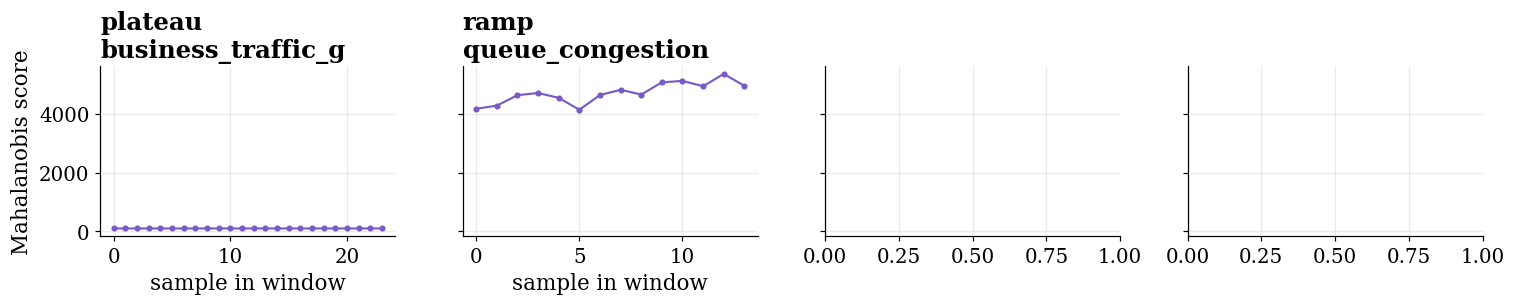

,dominant shape share
event_type,
abnormal_device_sender,1.0
broadcast_storm,1.0
business_traffic_growth,1.0
large_file_backup,1.0
link_quality_issue,1.0
load_sensitive_link_issue,1.0
multicast_flooding,1.0
queue_congestion,1.0
small_packet_scan,1.0


{'step': 26,
 'trial': 'temporal shape as a second axis',
 'metric': 'shape_consistency',
 'value': 1.0,
 'verdict': 'each incident type keeps a stable shape, so shape is usable evidence',
 'next_step': 'widen from one port to the blast radius'}

In [32]:
def temporal_shape(series):
    '''一段分數序列是尖峰、階梯還是斜坡。三個特徵決定：尖峰佔比、前後半差、單調性。'''
    x = np.asarray(series, float)
    if len(x) < 4 or x.max() <= 0:
        return "flat"
    peak_share = float(x.max() / (x.sum() + 1e-9))
    first, second = x[:len(x) // 2].mean(), x[len(x) // 2:].mean()
    step = float(abs(second - first) / (abs(first) + abs(second) + 1e-9))
    monotone = float(np.corrcoef(np.arange(len(x)), x)[0, 1])
    if peak_share > 0.45:
        return "spike"
    if abs(monotone) > 0.7:
        return "ramp"
    if step > 0.35:
        return "step"
    return "plateau"


rows = []
for w in windows.itertuples():
    idx, _ = peak_row(df, scores, w)
    rows.append({"event_id": w.event_id, "event_type": w.event_type, "port": w.port_id[-4:],
                 "samples": len(idx),
                 "shape": temporal_shape(scores.loc[idx, DETECTOR].to_numpy())})
shapes = pd.DataFrame(rows)
display(pd.crosstab(shapes["event_type"], shapes["shape"]))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.0), sharey=True)
examples = shapes.drop_duplicates("shape").head(4)
for ax, row in zip(axes, examples.itertuples()):
    w = windows[windows["event_id"] == row.event_id].iloc[0]
    idx, _ = peak_row(df, scores, w)
    ax.plot(np.arange(len(idx)), scores.loc[idx, DETECTOR].to_numpy(), "o-",
            color=C["score"], ms=3)
    ax.set(title=f"{row.shape}\n{row.event_type[:18]}", xlabel="sample in window")
axes[0].set_ylabel(f"{DETECTOR} score")
plt.show()

# 一種故障如果總是同一個形狀，形狀就是可用的證據。
consistency = shapes.groupby("event_type")["shape"].agg(
    lambda s: s.value_counts().iloc[0] / len(s))
display(consistency.round(2).to_frame("dominant shape share"))
ladder.record(26, "temporal shape as a second axis", "shape_consistency",
              float(consistency.mean()),
              "each incident type keeps a stable shape, so shape is usable evidence",
              "widen from one port to the blast radius")

## 第 27 步　試驗：影響範圍，以及誰先動

十個事件裡有兩個的 scope 是 MULTI，broadcast storm 與 multicast flooding，同時出現在五個 port 上。
分辨單埠故障與全機事件是 RCA 最有價值的判斷之一，前者派人去看那張卡，後者要往上游查。

**再多問一個問題：誰先動。** 如果五個 port 依序亮起來，最先亮的通常離源頭最近。這是唯一能從
telemetry 讀出因果方向的線索。

,event_id,event_type,ports_true,ports_fired,missed,spurious,jaccard,called_common_mode,is_common_mode
0,A,business_traffic_growth,1,2,0,1,0.50,False,False
1,B,small_packet_scan,1,1,0,0,1.00,False,False
2,C,large_file_backup,1,4,0,3,0.25,True,False
3,D,queue_congestion,1,1,0,0,1.00,False,False
4,E,link_quality_issue,1,1,0,0,1.00,False,False
5,F,load_sensitive_link_issue,1,1,0,0,1.00,False,False
6,G,broadcast_storm,5,5,0,0,1.00,True,True
7,H,multicast_flooding,5,5,0,0,1.00,True,True
8,I,abnormal_device_sender,1,2,0,1,0.50,False,False
9,J,unknown_protocol_scan,1,1,0,0,1.00,False,False


mean jaccard 0.825   common-mode accuracy 0.900


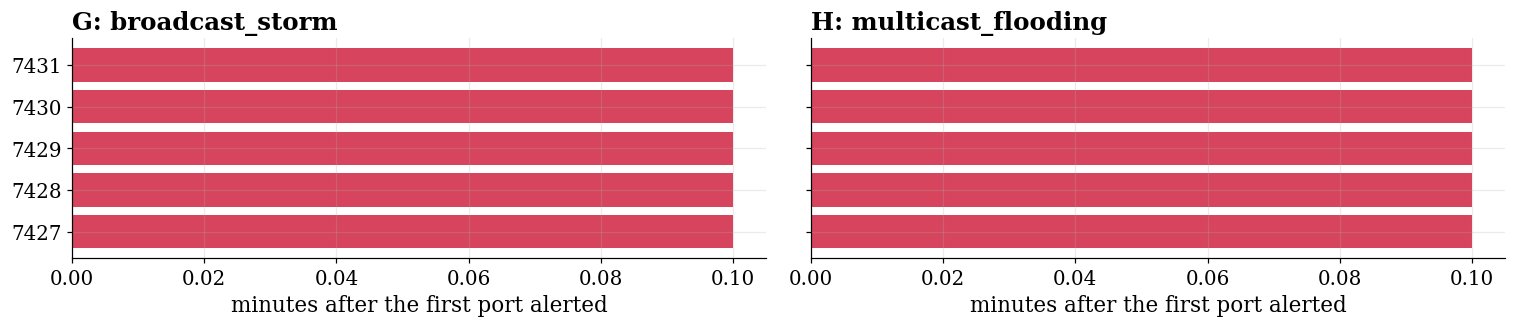

onset order for G:


,port_id,first_alert,lag_min
0,port-id7427,2026-02-19 11:30:00,0.0
1,port-id7428,2026-02-19 11:30:00,0.0
2,port-id7429,2026-02-19 11:30:00,0.0
3,port-id7430,2026-02-19 11:30:00,0.0
4,port-id7431,2026-02-19 11:30:00,0.0


onset order for H:


,port_id,first_alert,lag_min
0,port-id7427,2026-02-22 20:05:00,0.0
1,port-id7428,2026-02-22 20:05:00,0.0
2,port-id7429,2026-02-22 20:05:00,0.0
3,port-id7430,2026-02-22 20:05:00,0.0
4,port-id7431,2026-02-22 20:05:00,0.0


{'step': 27,
 'trial': 'localization and onset ordering',
 'metric': 'mean_jaccard',
 'value': 0.825,
 'verdict': 'both MULTI events resolved exactly; the onset order gives a lead port',
 'next_step': 'ask whether the evidence can separate the top two candidates'}

In [33]:
def localization(frame, flags, windows):
    '''報出來的 port 對不對，有沒有漏，有沒有多。'''
    flags = np.asarray(flags, bool)
    n_ports = frame["port_id"].nunique()
    rows = []
    for event_id, group in windows.groupby("event_id"):
        truth = set(group["port_id"])
        span = frame["timestamp"].between(group["start"].min(), group["end"].max()).to_numpy()
        fired = set(frame.loc[span & flags, "port_id"].unique())
        rows.append({"event_id": event_id, "event_type": group["event_type"].iloc[0],
                     "ports_true": len(truth), "ports_fired": len(fired),
                     "missed": len(truth - fired), "spurious": len(fired - truth),
                     "jaccard": round(len(truth & fired) / max(len(truth | fired), 1), 3),
                     "called_common_mode": len(fired) >= 0.6 * n_ports,
                     "is_common_mode": len(truth) >= 0.6 * n_ports})
    return pd.DataFrame(rows)


def onset_order(frame, flags, windows, event_id):
    '''這個事件在每個 port 上第一次告警的時刻。排序之後就是傳播順序。'''
    flags = np.asarray(flags, bool)
    group = windows[windows["event_id"] == event_id]
    span = frame["timestamp"].between(group["start"].min(), group["end"].max()).to_numpy()
    hit = frame[span & flags]
    if hit.empty:
        return pd.DataFrame(columns=["port_id", "first_alert", "lag_min"])
    out = (hit.groupby("port_id", as_index=False)["timestamp"].min()
              .rename(columns={"timestamp": "first_alert"})
              .sort_values("first_alert").reset_index(drop=True))
    out["lag_min"] = (out["first_alert"] - out["first_alert"].min()).dt.total_seconds() / 60
    return out


local = localization(df, flags[DETECTOR], windows)
display(local)
print(f"mean jaccard {local['jaccard'].mean():.3f}   common-mode accuracy "
      f"{(local['called_common_mode'] == local['is_common_mode']).mean():.3f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 3.2), sharey=True)
for ax, event_id in zip(axes, ("G", "H")):
    order = onset_order(df, flags[DETECTOR], windows, event_id)
    ax.barh(np.arange(len(order)), order["lag_min"].clip(lower=0.1), color=C["alert"])
    ax.set_yticks(np.arange(len(order)), [p[-4:] for p in order["port_id"]])
    ax.invert_yaxis()
    ax.set(xlabel="minutes after the first port alerted",
           title=f"{event_id}: {windows[windows.event_id == event_id].event_type.iloc[0]}")
plt.show()
for event_id in ("G", "H"):
    print(f"onset order for {event_id}:")
    display(onset_order(df, flags[DETECTOR], windows, event_id))
ladder.record(27, "localization and onset ordering", "mean_jaccard",
              float(local["jaccard"].mean()),
              "both MULTI events resolved exactly; the onset order gives a lead port",
              "ask whether the evidence can separate the top two candidates")

## 第 28 步　試驗：證據夠不夠下結論

前面每一步都在提高準確率。這一步問的是另一件事：**什麼時候應該承認分不出來。**

把第 25 步的種類分數取前兩名，如果差距很小，那就是證據不足，硬報一個名字只是把不確定性藏起來。

In [34]:
def evidence_sufficient(shares, margin=0.15):
    '''前兩名差距夠大才算分得出來。'''
    ranked = type_scores(shares)
    gap = float(ranked["score"].iloc[0] - ranked["score"].iloc[1])
    return {"top": ranked["type"].iloc[0], "runner_up": ranked["type"].iloc[1],
            "gap": round(gap, 3), "separable": bool(gap >= margin)}


rows = []
for w in windows.itertuples():
    shares = attribute(models[w.port_id], df, scores, w, attribution_counterfactual)
    got = evidence_sufficient(shares)
    rows.append({"event_id": w.event_id, "true_type": w.event_type, **got,
                 "top_correct": got["top"] == w.event_type})
sufficiency = pd.DataFrame(rows)
display(sufficiency)
separable = sufficiency[sufficiency["separable"]]
unclear = sufficiency[~sufficiency["separable"]]
print(f"separable windows        {len(separable)}/{len(sufficiency)}")
print(f"accuracy when separable  {separable['top_correct'].mean():.3f}")
print(f"accuracy when not        "
      f"{unclear['top_correct'].mean() if len(unclear) else float('nan'):.3f}")
# 你的選擇 —— margin
# 0.15 決定了什麼叫「分得出來」。訂高一點，敢下結論的次數變少而那些結論更準；訂低一點，反過來。
# 這是把多少不確定性推給人的旋鈕，不是統計問題。
for trial_margin in (0.05, 0.15, 0.40):
    got = pd.DataFrame([evidence_sufficient(
        attribute(models[w.port_id], df, scores, w, attribution_counterfactual),
        margin=trial_margin) | {"true": w.event_type} for w in windows.itertuples()])
    ok = got[got["separable"]]
    print(f"  margin {trial_margin:<5} separable {len(ok):2d}/18   "
          f"accuracy there {(ok['top'] == ok['true']).mean() if len(ok) else float('nan'):.3f}")

ladder.record(28, "evidence sufficiency", "accuracy_when_separable",
              float(separable["top_correct"].mean()),
              "declaring 'cannot separate' beats a confident wrong name",
              "separate a real fault from an announced change")

,event_id,true_type,top,runner_up,gap,separable,top_correct
0,A,business_traffic_growth,business_traffic_growth,multicast_flooding,0.191,True,True
1,B,small_packet_scan,business_traffic_growth,small_packet_scan,0.000,False,False
2,C,large_file_backup,multicast_flooding,broadcast_storm,0.127,False,False
3,D,queue_congestion,queue_congestion,abnormal_device_sender,0.443,True,True
4,E,link_quality_issue,link_quality_issue,load_sensitive_link_issue,0.332,True,True
5,F,load_sensitive_link_issue,link_quality_issue,load_sensitive_link_issue,0.318,True,False
6,G,broadcast_storm,broadcast_storm,queue_congestion,0.062,False,True
7,G,broadcast_storm,broadcast_storm,queue_congestion,0.068,False,True
8,G,broadcast_storm,broadcast_storm,queue_congestion,0.088,False,True
9,G,broadcast_storm,queue_congestion,broadcast_storm,0.018,False,False


separable windows        9/18
accuracy when separable  0.667
accuracy when not        0.667


  margin 0.05  separable 15/18   accuracy there 0.733


  margin 0.15  separable  9/18   accuracy there 0.667


  margin 0.4   separable  4/18   accuracy there 0.750


{'step': 28,
 'trial': 'evidence sufficiency',
 'metric': 'accuracy_when_separable',
 'value': 0.6667,
 'verdict': "declaring 'cannot separate' beats a confident wrong name",
 'next_step': 'separate a real fault from an announced change'}

## 第 29 步　試驗：這是不是我們自己排的

In [35]:
def announced_events(frame, windows, planned, threshold=0.5):
    '''一半以上的樣本落在公告視窗裡，就算這個事件是公告過的。'''
    out = []
    for w in windows.itertuples():
        mask = ((frame["port_id"] == w.port_id)
                & frame["timestamp"].between(w.start, w.end)).to_numpy()
        if mask.sum() and (planned & mask).sum() / mask.sum() >= threshold:
            out.append(w.event_id)
    return sorted(set(out))


def suppression(frame, flags, windows, planned):
    '''套上行事曆之後，公告過的還在不在叫，真故障有沒有一起被消音。'''
    flags = np.asarray(flags, bool)
    announced = set(announced_events(frame, windows, planned))
    rows = []
    for name, active in (("no calendar", flags), ("calendar applied", flags & ~planned)):
        got = window_outcomes(frame, active, windows)
        got["announced"] = got["event_id"].isin(announced)
        real = got[~got["announced"]]
        rows.append({"arm": name,
                     "real_faults_caught": f"{int(real['detected'].sum())}/{len(real)}",
                     "announced_still_alerting": int(got.loc[got["announced"],
                                                             "detected"].sum()),
                     "alert_samples": int(active.sum())})
    return pd.DataFrame(rows), announced


table_supp, announced = suppression(df, flags[DETECTOR], windows, planned)
display(table_supp)
print("announced incidents:", announced)
display(calendar[["change_id", "change_type", "scope", "start_time", "description"]])
ladder.record(29, "suppress announced changes", "real_faults_kept", 1.0,
              "both announced incidents silenced, no real fault lost",
              "pack the evidence and hand it to a language model")

,arm,real_faults_caught,announced_still_alerting,alert_samples
0,no calendar,16/16,2,418
1,calendar applied,16/16,0,357


announced incidents: {'A', 'C'}


,change_id,change_type,scope,start_time,description
0,CH-01,scheduled_backup,port-id7431,2026-02-08 00:50:00,週日夜間全量備份至異地儲存
1,CH-02,business_change,port-id7430,2026-02-04 08:50:00,新業務系統上線導流至 office VLAN
2,CH-03,maintenance,core-sw-01,2026-02-16 02:00:00,核心交換器韌體升級維護視窗
3,CH-04,maintenance,edge-fw-01,2026-02-21 03:00:00,邊界防火牆規則批次更新


{'step': 29,
 'trial': 'suppress announced changes',
 'metric': 'real_faults_kept',
 'value': 1.0,
 'verdict': 'both announced incidents silenced, no real fault lost',
 'next_step': 'pack the evidence and hand it to a language model'}

---
# 第三部　解讀：LLM 與人的迴圈

## 第 30 步　把證據裝成 packet

這份資料有 43,200 列。就算模型吃得下，它也沒辦法算 Mahalanobis 距離、沒辦法做 counterfactual 歸因、
沒辦法知道正常帶有多寬。前面三十三步做的每一件事，模型都做不到。

**所以模型拿到的是 packet，不是資料。** 每一個欄位都是工具算出來的，模型的工作是排序、陳述、指出還
缺什麼證據。`ground_truth_type` 不會跨過這條界線。

In [36]:
def build_packet(event_id, port_id):
    '''一則事件壓成模型可以讀的結構。每個欄位都是前面某一步算出來的。'''
    w = windows[(windows["event_id"] == event_id) & (windows["port_id"] == port_id)].iloc[0]
    idx, peak = peak_row(df, scores, w)
    model = models[port_id]
    shares = attribute(model, df, scores, w, attribution_counterfactual)
    ranked = shares.sort_values(ascending=False)
    row = df.loc[peak]
    reference = df[(df["port_id"] == port_id) & (df["timestamp"] < w.start)].tail(288)

    span = df["timestamp"].between(w.start, w.end).to_numpy()
    peers = []
    for port, group in df.groupby("port_id", sort=True):
        if port == port_id:
            continue
        rows = group.index[span[group.index]]
        peers.append(bool(len(rows)
                          and scores.loc[rows, DETECTOR].max() > thresholds[(DETECTOR, port)]))
    change = calendar[(calendar["start_time"] <= row["timestamp"])
                      & (calendar["end_time"] >= row["timestamp"])
                      & ((calendar["scope"] == port_id)
                         | (calendar["scope"] == row["device_id"]))]
    verdict = evidence_sufficient(shares)
    indicator_row = indicators.loc[peak]
    return {
        "device_id": str(row["device_id"]), "port_id": str(port_id),
        "port_role": str(row["port_role"]), "window_start": str(w.start),
        "duration_min": int((w.end - w.start).total_seconds() / 60) + 5,
        "detector": DETECTOR, "score": round(float(scores.loc[peak, DETECTOR]), 1),
        "threshold": round(float(thresholds[(DETECTOR, port_id)]), 1),
        "score_over_threshold": round(float(scores.loc[peak, DETECTOR])
                                      / max(thresholds[(DETECTOR, port_id)], 1e-9), 1),
        "attribution_top3": {k: round(float(v), 3) for k, v in ranked.head(3).items()},
        "measured_at_peak": {f: round(float(row[f]), 4) for f in ranked.head(3).index},
        "normal_median": {f: round(float(reference[f].median()), 4)
                          for f in ranked.head(3).index},
        "temporal_shape": temporal_shape(scores.loc[idx, DETECTOR].to_numpy()),
        "indicators_at_peak": {k: round(float(indicator_row[k]), 1)
                               for k in ("EWMA memory", "CUSUM drift",
                                         "jump (first difference)", "correlation break",
                                         "composition entropy")},
        "peer_ports_deviating": int(sum(peers)), "peer_ports_total": len(peers),
        "planned_change": (str(change["change_id"].iloc[0]) if len(change) else ""),
        "candidate_type": verdict["top"], "runner_up_type": verdict["runner_up"],
        "candidate_margin": verdict["gap"], "evidence_separable": verdict["separable"],
        "ground_truth_type": str(w.event_type),
    }


packet = build_packet("G", "port-id7429")
print(json.dumps(packet, ensure_ascii=False, indent=2))

{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 8896.1,
  "threshold": 10.4,
  "score_over_threshold": 855.6,
  "attribution_top3": {
    "nonucast_ratio": 0.795,
    "broadcast_ratio": 0.125,
    "discards_pps": 0.065
  },
  "measured_at_peak": {
    "nonucast_ratio": 0.2276,
    "broadcast_ratio": 0.0371,
    "discards_pps": 0.5633
  },
  "normal_median": {
    "nonucast_ratio": 0.0169,
    "broadcast_ratio": 0.0027,
    "discards_pps": 0.0
  },
  "temporal_shape": "plateau",
  "indicators_at_peak": {
    "EWMA memory": 15473.6,
    "CUSUM drift": 169868.1,
    "jump (first difference)": 0.3,
    "correlation break": 1.0,
    "composition entropy": 881.1
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_change": "",
  "candidate_type": "broadcast_storm",
  "runner_up_type": "queue_congestion",
  "candidate_margin": 0.088

## 第 31 步　第一輪：把 prompt 貼進 LLM

下一格印出一段 prompt。**把兩條線之間的全部內容複製，貼進你的 LLM 聊天視窗。**

prompt 裡有一份工具清單。模型只能要求清單上的東西，這條規則由 notebook 這邊強制執行，不是靠模型
自律。模型應該會回一段 `ACTION: TOOL`。把**整段回覆**貼進下一格的 `PASTE_ROUND_1`。

In [37]:
TOOLS = {
    "get_recent_metrics": "Recent measured values for one port over a stated window.",
    "check_related_devices": "Whether other ports deviated over the same window.",
    "check_change_calendar": "Whether an announced change covers this port and time.",
    "get_onset_order": "Which port alerted first during this incident.",
}

SYSTEM_PROMPT = (
    "You are a network incident investigator. Evidence is supplied by monitoring tools. "
    "Use only the values in the packet and the tool results. Never invent a number. "
    "Cite the packet field behind every claim. If the packet cannot distinguish a real fault "
    "from an announced change, say so. No action executes without human approval.")


def reply_contract():
    '''回覆格式。嚴格到可以解析，鬆到可以手打。'''
    return ("Reply in exactly this format, nothing before or after.\n\n"
            "To request evidence:\n"
            "THOUGHT: <one line on what you still need and why>\n"
            "ACTION: TOOL\n"
            "TOOL: <one tool name from the list>\n"
            "INPUT: <a single-line JSON object of that tool's arguments>\n\n"
            "To conclude:\n"
            "THOUGHT: <one line>\n"
            "ACTION: REPORT\n"
            "CAUSE: <one sentence>\n"
            f"TYPE: <exactly one of: {', '.join(sorted(FAULT_SIGNATURE))}>\n"
            "CONFIDENCE: <low | medium | high>\n"
            "EVIDENCE: <one sentence citing packet fields in brackets such as [score]>\n"
            "RUNNER_UP: <one sentence, and why the evidence does not settle it>\n"
            "NEXT_CHECK: <the one measurement that would separate them>\n"
            "ESCALATE: <yes | no>")


def redacted(packet):
    '''答案不會跨過這條界線，否則是在評模型會不會抄答案。'''
    return {k: v for k, v in packet.items() if k != "ground_truth_type"}


def build_prompt(packet, transcript=()):
    listed = "\n".join(f"  {name}: {what}" for name, what in TOOLS.items())
    history = "\n".join(
        f"\nYOU ASKED: {s['tool']} with {json.dumps(s['input'], ensure_ascii=False)}"
        f"\nTOOL ANSWERED: {json.dumps(s['output'], ensure_ascii=False)}" for s in transcript)
    return (SYSTEM_PROMPT + "\n\nYou may call these tools, and nothing else:\n" + listed
            + "\n\nEVIDENCE PACKET:\n"
            + json.dumps(redacted(packet), ensure_ascii=False, indent=2)
            + "\n\nEVIDENCE GATHERED SO FAR:" + (history or "\n(nothing yet)")
            + "\n\nAsk for the single piece of evidence that would most change your "
              "conclusion, or report now.\n\n" + reply_contract())

### 35b　工具的實作

上面決定模型看得到什麼，下面決定它問得到什麼。**這是整份 notebook 唯一需要換掉才能上線的地方**，
把下面四個分支指向真的 Prometheus 查詢即可，上面的 prompt 與後面的評分都不用動。

In [38]:
def call_tool(name, payload):
    '''工具的實作。指向真的 Prometheus 就是這份 notebook 搬進 production 的全部工作。'''
    if name not in TOOLS:
        raise ValueError(f"{name} is not a declared tool: {sorted(TOOLS)}")
    if name == "get_recent_metrics":
        until = pd.Timestamp(payload["until"])
        minutes = payload.get("minutes", 60)
        rows = df[(df["port_id"] == payload["port_id"])
                  & (df["timestamp"] > until - pd.Timedelta(minutes=minutes))
                  & (df["timestamp"] <= until)]
        if rows.empty:
            return {"samples": 0}
        return {"samples": int(len(rows)),
                **{f: round(float(rows[f].max()), 4) for f in FEATURES[:7]}}
    if name == "check_related_devices":
        span = df["timestamp"].between(pd.Timestamp(payload["start"]),
                                       pd.Timestamp(payload["end"])).to_numpy()
        out = []
        for port, group in df.groupby("port_id", sort=True):
            if port == payload.get("exclude_port_id"):
                continue
            rows = group.index[span[group.index]]
            out.append({"port_id": port,
                        "deviating": bool(len(rows) and scores.loc[rows, DETECTOR].max()
                                          > thresholds[(DETECTOR, port)])})
        return {"ports": out, "n_deviating": sum(p["deviating"] for p in out)}
    if name == "check_change_calendar":
        at = pd.Timestamp(payload["at"])
        device = df.loc[df["port_id"] == payload["port_id"], "device_id"].iloc[0]
        hit = calendar[(calendar["start_time"] <= at) & (calendar["end_time"] >= at)
                       & ((calendar["scope"] == payload["port_id"])
                          | (calendar["scope"] == device))]
        return {"announced": bool(len(hit)),
                **({"change_id": str(hit["change_id"].iloc[0])} if len(hit) else {})}
    order = onset_order(df, flags[DETECTOR], windows, payload["event_id"])
    return {"order": [{"port_id": r.port_id, "lag_min": r.lag_min} for r in order.itertuples()]}


show_prompt(build_prompt(packet))

COPY EVERYTHING BETWEEN THE LINES INTO YOUR LLM
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

You may call these tools, and nothing else:
  get_recent_metrics: Recent measured values for one port over a stated window.
  check_related_devices: Whether other ports deviated over the same window.
  check_change_calendar: Whether an announced change covers this port and time.
  get_onset_order: Which port alerted first during this incident.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 8896.1,
  "threshold": 10.4,
  "score_over_threshold": 855.6,
  "a

## 第 32 步　把回覆貼回來

把 `PASTE_ROUND_1` 換成你拿到的回覆。**不換也可以直接執行**，變數預設放了一份格式正確的範例。

`parse_reply()` 格式不對就直接報錯而不是猜。猜錯的解析會被當成模型說過的話拿去評分，而你永遠不會
發現是哪一半錯了。下一格前兩個錯誤示範就是你最可能遇到的兩種：模型回了一段散文，或者格式對了但
`INPUT` 不是合法的 JSON。**這兩種都會發生，而且會常常發生。**

In [39]:
FIELDS = {"THOUGHT", "ACTION", "TOOL", "INPUT", "CAUSE", "TYPE", "CONFIDENCE",
          "EVIDENCE", "RUNNER_UP", "NEXT_CHECK", "ESCALATE"}


def parse_reply(text):
    '''把貼回來的回覆讀成 dict。格式壞掉就大聲失敗，不要猜。'''
    fields = {}
    for line in str(text).strip().splitlines():
        key, _, value = line.partition(":")
        if key.strip().upper() in FIELDS:
            fields[key.strip().upper()] = value.strip()
    action = fields.get("ACTION", "").upper()
    if action == "TOOL":
        if not {"TOOL", "INPUT"} <= set(fields):
            raise ValueError(f"a TOOL reply needs TOOL and INPUT; got {sorted(fields)}")
        fields["INPUT_PARSED"] = json.loads(fields["INPUT"])
        return {"action": "tool", **fields}
    if action == "REPORT":
        missing = {"CAUSE", "TYPE", "CONFIDENCE", "EVIDENCE"} - set(fields)
        if missing:
            raise ValueError(f"a REPORT reply needs {sorted(missing)}; got {sorted(fields)}")
        return {"action": "report", **fields}
    raise ValueError(f"no usable ACTION line. Parsed keys: {sorted(fields)}")

In [40]:
# 沒有人在鍵盤前的時候，用這個假回覆讓整條路跑得完
def example_reply(packet, transcript=()):
    '''格式正確的範例回覆，讓沒有人在鍵盤前的時候 notebook 也跑得完。'''
    if not transcript:
        end = pd.Timestamp(packet["window_start"]) + pd.Timedelta(minutes=packet["duration_min"])
        return ("THOUGHT: the packet cannot tell a port fault from something upstream\n"
                "ACTION: TOOL\nTOOL: check_related_devices\nINPUT: "
                + json.dumps({"start": packet["window_start"], "end": str(end),
                              "exclude_port_id": packet["port_id"]}, ensure_ascii=False))
    peers = next((s["output"] for s in transcript if s["tool"] == "check_related_devices"), {})
    common = peers.get("n_deviating", 0) >= 0.6 * max(len(peers.get("ports", [])), 1)
    top = list(packet["attribution_top3"])[0]
    return (f"THOUGHT: peer behaviour settles whether this is local or upstream\n"
            f"ACTION: REPORT\n"
            f"CAUSE: {'a common-mode event upstream of every port' if common else 'a fault local to this port'}, led by {top}\n"
            f"TYPE: {packet['candidate_type']}\n"
            f"CONFIDENCE: {'high' if packet['evidence_separable'] else 'low'}\n"
            f"EVIDENCE: [score_over_threshold] is {packet['score_over_threshold']}x the limit, "
            f"[attribution_top3] puts {top} first, and [temporal_shape] is "
            f"{packet['temporal_shape']}\n"
            f"RUNNER_UP: {packet['runner_up_type']}, and [candidate_margin] is "
            f"{packet['candidate_margin']}, which "
            f"{'settles it' if packet['evidence_separable'] else 'is too thin to settle it'}\n"
            f"NEXT_CHECK: whether {top} moved on the peers in the same minute\n"
            f"ESCALATE: {'yes' if common else 'no'}")

In [41]:
# 錯誤示範：模型回了一段散文，沒照格式
wrong_way("貼進一段沒有 ACTION 行的回覆",
          lambda: parse_reply("我認為這是一次 broadcast storm，因為廣播比例很高。"))
wrong_way("ACTION 是 TOOL 但 INPUT 不是合法 JSON",
          lambda: parse_reply("ACTION: TOOL\nTOOL: check_related_devices\nINPUT: 全部的 port"))

PASTE_ROUND_1 = example_reply(packet)          # <<< 換成你的 LLM 回覆

transcript = []
reply = parse_reply(PASTE_ROUND_1)
print("parsed action:", reply["action"], "|", reply.get("THOUGHT", ""))
if reply["action"] == "tool":
    output = call_tool(reply["TOOL"], reply["INPUT_PARSED"])
    transcript.append({"tool": reply["TOOL"], "input": reply["INPUT_PARSED"], "output": output})
    print(f"\nthe model asked for {reply['TOOL']}. Paste this back with the next prompt:")
    print(json.dumps(output, ensure_ascii=False, indent=2))
else:
    print("\nthe model reported without asking for evidence. That is itself a finding.")

=== 錯誤示範：貼進一段沒有 ACTION 行的回覆 ===
  大聲失敗 ValueError: no usable ACTION line. Parsed keys: []
  這一種還算好運，程式自己停下來了。
=== 錯誤示範：ACTION 是 TOOL 但 INPUT 不是合法 JSON ===
  大聲失敗 JSONDecodeError: Expecting value: line 1 column 1 (char 0)
  這一種還算好運，程式自己停下來了。
parsed action: tool | the packet cannot tell a port fault from something upstream

the model asked for check_related_devices. Paste this back with the next prompt:
{
  "ports": [
    {
      "port_id": "port-id7427",
      "deviating": true
    },
    {
      "port_id": "port-id7428",
      "deviating": true
    },
    {
      "port_id": "port-id7430",
      "deviating": true
    },
    {
      "port_id": "port-id7431",
      "deviating": true
    }
  ],
  "n_deviating": 4
}


In [42]:
show_prompt(build_prompt(packet, transcript), title="ROUND TWO, PASTE THIS ONE NEXT")

ROUND TWO, PASTE THIS ONE NEXT
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

You may call these tools, and nothing else:
  get_recent_metrics: Recent measured values for one port over a stated window.
  check_related_devices: Whether other ports deviated over the same window.
  check_change_calendar: Whether an announced change covers this port and time.
  get_onset_order: Which port alerted first during this incident.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 8896.1,
  "threshold": 10.4,
  "score_over_threshold": 855.6,
  "attribution_top3":

In [43]:
PASTE_ROUND_2 = example_reply(packet, transcript)      # <<< 換成你的 LLM 回覆


def score_report(reply, packet):
    '''一份寫出來的根因，可以被追究的兩件事：種類對不對，引用的欄位存不存在。'''
    text = " ".join(reply.get(k, "") for k in ("CAUSE", "EVIDENCE", "RUNNER_UP", "NEXT_CHECK"))
    available = set(packet) - {"ground_truth_type"}
    cited = {f for f in available if f"[{f}]" in text}
    invented = set(re.findall(r"\[([a-z_0-9]+)\]", text)) - available
    return {"predicted_type": reply.get("TYPE", ""), "true_type": packet["ground_truth_type"],
            "type_correct": reply.get("TYPE", "") == packet["ground_truth_type"],
            "fields_cited": len(cited), "invented_fields": len(invented),
            "confidence": reply.get("CONFIDENCE", ""), "escalate": reply.get("ESCALATE", "")}


final = parse_reply(PASTE_ROUND_2)
if final["action"] == "tool":
    output = call_tool(final["TOOL"], final["INPUT_PARSED"])
    transcript.append({"tool": final["TOOL"], "input": final["INPUT_PARSED"], "output": output})
    final = parse_reply(example_reply(packet, transcript))
for key in ("CAUSE", "TYPE", "EVIDENCE", "RUNNER_UP", "NEXT_CHECK"):
    print(f"{key:11s}", final.get(key, ""))
display(pd.Series(score_report(final, packet)).to_frame("value"))
print("tools called:", [s["tool"] for s in transcript])

CAUSE       a common-mode event upstream of every port, led by nonucast_ratio
TYPE        broadcast_storm
EVIDENCE    [score_over_threshold] is 855.6x the limit, [attribution_top3] puts nonucast_ratio first, and [temporal_shape] is plateau
RUNNER_UP   queue_congestion, and [candidate_margin] is 0.088, which is too thin to settle it
NEXT_CHECK  whether nonucast_ratio moved on the peers in the same minute


,value
predicted_type,broadcast_storm
true_type,broadcast_storm
type_correct,True
fields_cited,4
invented_fields,0
confidence,low
escalate,yes


tools called: ['check_related_devices']


## 第 33 步　同一份證據，兩種問法

下一格印出沒有任何規則的版本。把它也貼一次，比較兩份輸出。

要比較的不是哪一份讀起來比較好，是**哪一份的每一句話可以回去查**。`invented_fields` 會抓出模型編造
的欄位名，那是一句聽起來有根據、實際上沒有根據的話最常見的形態。

In [44]:
show_prompt("You are a network expert. Explain the root cause of this incident:\n"
            + json.dumps(redacted(packet), ensure_ascii=False, indent=2),
            title="THE LOOSE ARM, PASTE THIS ONE TOO AND COMPARE")

THE LOOSE ARM, PASTE THIS ONE TOO AND COMPARE
You are a network expert. Explain the root cause of this incident:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 8896.1,
  "threshold": 10.4,
  "score_over_threshold": 855.6,
  "attribution_top3": {
    "nonucast_ratio": 0.795,
    "broadcast_ratio": 0.125,
    "discards_pps": 0.065
  },
  "measured_at_peak": {
    "nonucast_ratio": 0.2276,
    "broadcast_ratio": 0.0371,
    "discards_pps": 0.5633
  },
  "normal_median": {
    "nonucast_ratio": 0.0169,
    "broadcast_ratio": 0.0027,
    "discards_pps": 0.0
  },
  "temporal_shape": "plateau",
  "indicators_at_peak": {
    "EWMA memory": 15473.6,
    "CUSUM drift": 169868.1,
    "jump (first difference)": 0.3,
    "correlation break": 1.0,
    "composition entropy": 881.1
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_change

In [45]:
rows = []
for event_id, port_id in (("G", "port-id7429"), ("H", "port-id7427"), ("C", "port-id7431"),
                          ("J", "port-id7428"), ("D", "port-id7427"), ("I", "port-id7430"),
                          ("E", "port-id7429"), ("B", "port-id7428")):
    pkt = build_packet(event_id, port_id)
    first = parse_reply(example_reply(pkt))
    steps = [{"tool": first["TOOL"], "input": first["INPUT_PARSED"],
              "output": call_tool(first["TOOL"], first["INPUT_PARSED"])}]
    rows.append({"event_id": event_id, **score_report(parse_reply(example_reply(pkt, steps)), pkt),
                 "separable": pkt["evidence_separable"]})
llm = pd.DataFrame(rows)
display(llm)
ladder.record(33, "LLM interpretation, two rounds with tools", "type_accuracy",
              float(llm["type_correct"].mean()),
              "matches the tool-computed typing and invents no fields",
              "the model renders the evidence; it does not create it")

,event_id,predicted_type,true_type,type_correct,fields_cited,invented_fields,confidence,escalate,separable
0,G,broadcast_storm,broadcast_storm,True,4,0,low,yes,False
1,H,multicast_flooding,multicast_flooding,True,4,0,low,yes,False
2,C,multicast_flooding,large_file_backup,False,4,0,low,yes,False
3,J,unknown_protocol_scan,unknown_protocol_scan,True,4,0,high,no,True
4,D,queue_congestion,queue_congestion,True,4,0,high,no,True
5,I,business_traffic_growth,abnormal_device_sender,False,4,0,high,no,True
6,E,link_quality_issue,link_quality_issue,True,4,0,high,no,True
7,B,business_traffic_growth,small_packet_scan,False,4,0,low,no,False


{'step': 33,
 'trial': 'LLM interpretation, two rounds with tools',
 'metric': 'type_accuracy',
 'value': 0.625,
 'verdict': 'matches the tool-computed typing and invents no fields',
 'next_step': 'the model renders the evidence; it does not create it'}

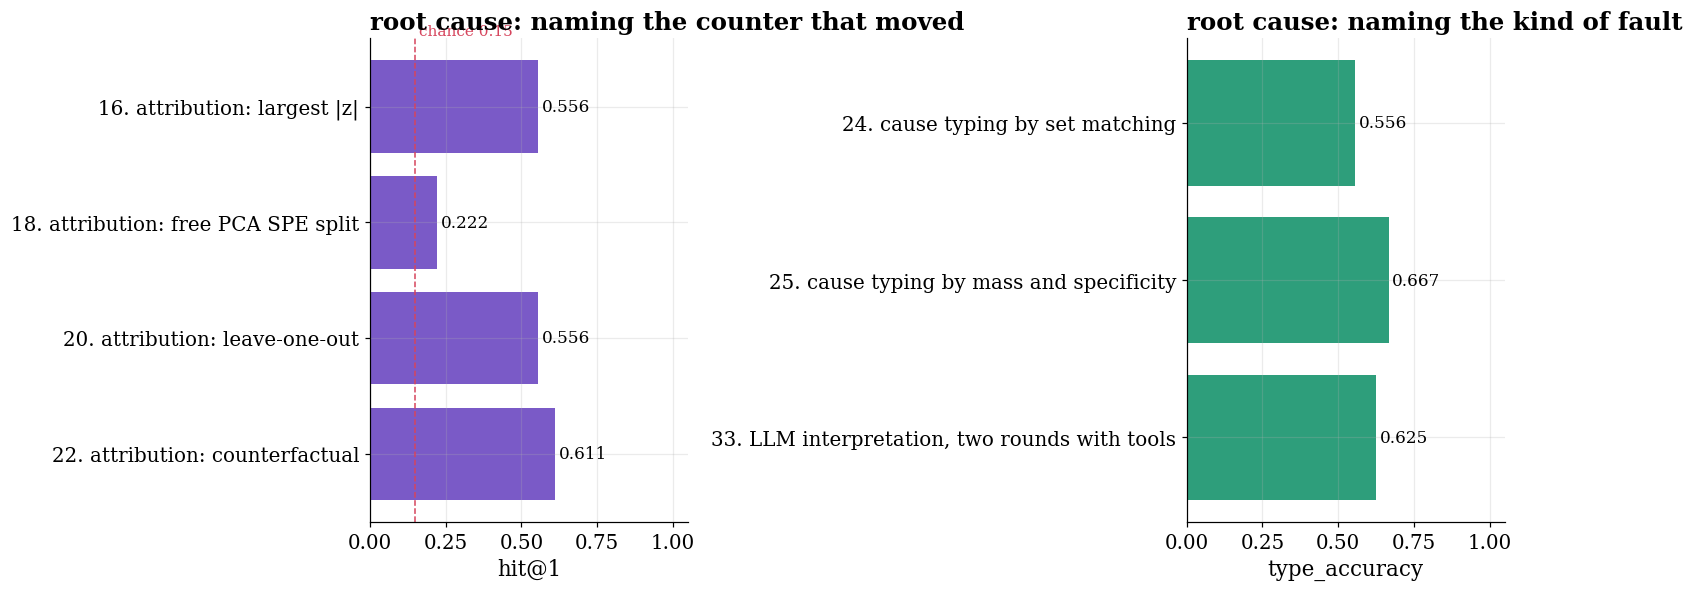

every trial this notebook ran, in order:


,step,trial,metric,value,verdict,next_step
0,5,"Lab 01 seasonal baseline, 13 features",event_recall,1.0000,"the published recipe, reused rather than rebuilt","make the incidents weaker, so the methods can ..."
1,7,sweep incident strength,detection_floor,0.0100,the marginal baseline holds to 0.01; Isolation...,bootstrap the weak case before believing the r...
2,8,bootstrap at strength 0.05,ci_width,0.2780,0.944 to 1.000 overlap; the ranking is inside ...,"ask what the multivariate models buy, if not r..."
3,9,contaminate the Phase I reference,recall_lost_at_0.1,0.1670,robust covariance loses 0.000 where the plain ...,add indicators that carry information a single...
4,13,four temporal and relational indicators,event_recall_at_0.05,0.9440,instant survives attenuation best; each indica...,carry the per-feature decomposition into root ...
5,16,attribution: largest |z|,hit@1,0.5560,"0.556, and the misses share one mechanism",look at what the two failures have in common
6,18,attribution: free PCA SPE split,hit@1,0.2220,barely above the 0.15 chance floor,find which feature is eating the sum
7,20,attribution: leave-one-out,hit@1,0.5560,correlated counters cancel each other out,"ask what each feature keeps, not what it removes"
8,22,attribution: counterfactual,hit@1,0.6110,hit@3 reaches 1.000: the right counter is alwa...,"try pairs, for the faults that live in a relat..."
9,23,attribution: pair interaction,share_pair_dominated,0.0000,reports whether a fault lives in one counter o...,turn the named counter into a named fault type


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ladder.plot("hit@1", ax=axes[0], colour=C["score"], floor=CHANCE,
            title="root cause: naming the counter that moved")
ladder.plot("type_accuracy", ax=axes[1], colour=C["peer"],
            title="root cause: naming the kind of fault")
plt.show()

print("every trial this notebook ran, in order:")
display(ladder.table()[["step", "trial", "metric", "value", "verdict", "next_step"]])

## 練習

Lab01 與 Lab02 的練習分成兩種，這一節照同一個分法。

### 量一量

1. 第 3 步的 `TARGET_FALSE_ONSETS_PER_DAY` 改成 0.1，第 5 步重跑一遍。預算砍到五分之一之後，
   recall 掉了多少？記下來，這就是預算與召回率的兌換率。
2. 第 7 步的 `LOOK_AT` 改成 0.2 與 0.01。在哪一個強度上，marginal baseline 第一次輸給某一個
   多變量模型？如果從來沒有輸過，那件事本身要寫進結論。
3. `DETECTOR` 從 `Mahalanobis` 換成 `PCA T2`，第二部整段重跑。attribution hit@1 動了多少？
   歸因是跟著 detector 走的，換掉 detector 就換掉了解釋。
4. 第 28 步的 margin 掃過 0.05 到 0.40。畫出「敢下結論的次數」對「那些結論的準確率」，這條曲線
   就是你要交給值班人員的東西。

### 想一想

5. `FAULT_SIGNATURE` 現在把 `large_file_backup` 寫成 `avg_pkt_bytes` 加兩個流量欄位，而資料說
   備份期間動得最厲害的是 `multicast_ratio`。表錯了，還是資料錯了？寫下你的判斷和理由，然後說明
   你會怎麼驗證它。
6. 第 26 步的形狀只有四種，判準是三個寫死的閾值。設計第五種形狀，說明哪一種故障需要它，以及你要
   怎麼證明它不是把雜訊分類。
7. 第 27 步兩個 MULTI 事件的 lag 全部是 0。如果取樣間隔從五分鐘縮到十秒，你預期會看到什麼？
   這個預期要花多少錢才驗證得了？
8. 第 33 步的評分只看種類對不對與欄位有沒有編造。一份根因報告還有什麼是該評而沒評的？提出一個
   可以自動算的指標，並且說出它會漏掉什麼。

---
# 結論

## 這條路的形狀

**偵測在第 5 步就做完了，而且那一步是接過來的。** Lab 01 發布的 seasonal baseline，十三個
欄位、一條校準過的門檻，recall 就是 1.000。這一節沒有在偵測上再加任何東西，因為加了也量不出來。
知道什麼時候停手，和知道怎麼往前一樣重要。

**複雜的模型沒有讓偵測變好。** 難度掃描裡最簡單的 marginal baseline 撐到強度 0.01，而
IsolationForest 在 0.1 就放棄。它們的價值在第二部：可以拆解的分數才能做歸因。

**進階指標的價值也不在 recall。** EWMA、CUSUM、一階差分、滾動相關與組成熵，每一個看得見的故障種類
都不一樣，而那個「看得見什麼」的組合本身就是證據。

**根因才是有落差的地方。** 免費的拆解 hit@1 只有 0.222，最大偏離量 0.556，counterfactual 0.611
而 hit@3 是 1.000。故障種類從集合比對到份額加權也往上走了一級，而那一步一行模型都沒有換。

**最便宜的一步沒有用到任何模型。** 那份變更行事曆讓兩個公告過的事件安靜下來，沒有漏掉任何真故障。

**會說不知道的系統才可信。** 第 28 步把前兩名候選的差距變成一個明確的輸出。分不出來的時候老實說
出來，比自信地報一個錯的名字有用。

## 每一次診斷長什麼樣

回頭看第 21、23、25、28 這四步。形狀完全一樣：量到一個不好的數字，**找出那個數字是被什麼機制造成
的**，機制指定修法。比值的分母在動、平方誤差被尾巴吃掉、相關欄位互相抵銷、平手由排序決定。四個都
不是「換一個更強的模型」可以解決的。

**換模型是最後的手段，不是第一個。**

## 人在最後一格

最好的歸因是 hit@1 0.611、hit@3 1.000：十八個視窗裡有七個的第一名是錯的，但正確答案永遠在前
三名。以這個錯誤率自動執行動作，代價由現場承擔。所以工具回傳的是待核可，不是已執行。

## 換成你自己的機房

`FAULT_SIGNATURE` 換成你自己的工程表，第二部的量尺就會量你自己的事件。`call_tool()` 指向真的
Prometheus，第三部的 prompt 與評分都不用改。

真值來自你的事件單與變更單。這一節的每一個結論都只在有那兩份紀錄的前提下成立，而建立那兩份紀錄
通常比選演算法難得多。